In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import sys
sys.path.append("/content/drive/MyDrive/stocks/duet/duet_class")

from pipeline.config import DUETConfig
from pipeline import train, evaluate, predict
from pipeline.prepare_and_check import FinancialTimeSeriesPreparer
from pipeline.timefeatures import time_features_from_index
from pipeline.wf_slicer import GlobalNormConfig, SplitConfig, WalkForwardWindowSlicerVec, WindowConfig
from duet.model import DUETModel
from torch.utils.data import DataLoader, TensorDataset
import torch
import joblib
import random

import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight


In [3]:
# Настройки
DATA_PATH = "/content/drive/MyDrive/stocks/Data/anomaly/anomaly_df_binance_BTCUSDT_futures_cufOff_1.5.joblib"

device = "cuda" if torch.cuda.is_available() else "cpu"

config = DUETConfig(
    # =========================
    # Общие параметры
    # =========================
    split_ratio = (1.0, 0.0, 0.0),
    timestamp_col = "timestamp",
    features = [
       'Open', 'High', 'Low', 'Close',
      #  'Volume',
    ],                           # Название колонок для обучения
    forecast = 'target',          # Название колонки с таргетом
    # нормализация не нужна (дуэт все делает сам внутри себя)
    #============================
    not_to_normalise = [],       # Название колонок, которые НЕ НАДО нормализовать
    scaler = 'NONE',             # Тип нормализации (STD, MINMAX, QUANT)
    #============================
    y_end_offset = 0,             # Смещение таргета: Детекция t0=0 или предикт t+1..N=+1...+N
    x_end_offset=+20,              # Смещение инпута в будущее: t0=0, t+1...N = +1...+N
    seq_len = 110,                # Длина входной последовательности
    num_classes = 7,             # кол-во классов
    patch_len = 60,               # Длина патча (TCM)
    stride = 20,                  # Шаг между патчами (TCM)
    moving_avg = 25,              # Размер окна скользящего сглаживания

    K_t = 3,                    # Кол-во временных кластеров (TCM)
    K_c = 9,                    # Кол-во кластеров каналов (CCM)
    d_c = 128,                   # Размерность embedding каналов (CCM)
    top_k = 5,                  # Кол-во связей при разреживании маски
    use_revin = True,           # Включить RevIN/InstanceNorm (если отключить, то нужно нормализовать данные отдельно)
    revin_affine = True,        # Использовать affine параметры в RevIN
    revin_eps = 1e-5,           # Эпсилон для стабильности RevIN

    # =========================
    # Параметры модели
    # =========================
    d_model = 256,               # Размерность скрытого пространства в attention
    d_ff = 1024,                 # Размерность feedforward слоя
    n_heads = 4,                # Количество голов в multi-head attention
    e_layers = 2,               # Количество слоев в encoder (CCM)
    dropout = 0.1,            # Dropout во всех слоях attention
    fc_dropout = 0.1,         # Dropout в выходном head слое
    activation = "relu",        # Активационная функция (relu, gelu, elu)
    num_experts = 8,            # Число экспертов (в Router, если используется)
    report_freq = 10,            # Частота появления confusion matrix

    # =========================
    # Режимы обработки
    # =========================
    CI = True,                 # Channel-Independent режим (если False — shared weights)
    use_router = True,          # Включить распределительный роутер
    timeenc = 1,                # Использовать time encoding (0 = без, 1 = sin/cos и т.п.)

    # =========================
    # Настройки обучения
    # =========================
    batch_size=32,          # можно немного увеличить при хорошем GPU
    epochs=100,             # больше эпох для более тонкой настройки
    learning_rate=1e-4,     # стандартный LR для Adam
    weight_decay=1e-5,
    patience=100,            # early stopping не слишком строгий

    # =========================
    # Прочее
    # =========================
    checkpoint_best = '/content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_005.pt',       # Путь для сохранения лучших по val_accuracy весов
    checkpoint_final = '/content/drive/MyDrive/stocks/duet/duet_class/weights/final_weights_005.pt',      # Путь для сохранения финальных весов
    seed = 33,                  # Фиксированное зерно генератора случайных чисел
    verbose = True,            # Печать хода обучения
)

"""
Устанавливает seed для numpy, random, torch (вкл. CUDA).
Гарантирует воспроизводимость.
"""

random.seed(config.seed)
np.random.seed(config.seed)
torch.manual_seed(config.seed)
torch.cuda.manual_seed_all(config.seed)

In [4]:
# --- 1. Предобработка данных ---
# Загрузка данных
df = joblib.load(DATA_PATH)

data_preparer = FinancialTimeSeriesPreparer(
    tz="UTC",
    timestamp_col="timestamp",
    drop_warmup=True,
)

df, _ = data_preparer.prepare(df, ensure_ohlcv=True, from_date="2021-01-01", to_date="2025-12-30")

time_features = time_features_from_index(df.index, timeenc=config.timeenc)
time_feature_names = [f"timeenc_{i}" for i in range(time_features.shape[1])]
df[time_feature_names] = time_features
config.features = config.features + time_feature_names


In [5]:
# @title Доп. индикаторы
import pandas as pd
import numpy as np
from typing import Tuple

def calculate_rsi(df: pd.DataFrame, column: str, window: int = 14) -> pd.Series:
    # Вычисляем разницу между текущим и предыдущим значением цены
    delta = df[column].diff()

    # Выбираем положительные и отрицательные изменения
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    # Скользящее среднее приростов и падений
    avg_gain = gain.rolling(window=window, min_periods=window).mean()
    avg_loss = loss.rolling(window=window, min_periods=window).mean()

    # Вычисляем RS и RSI
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi

def calculate_bollinger_bands(df: pd.DataFrame, column: str, window: int = 20, num_std: int = 2) -> Tuple[pd.Series]:
    # Среднее значение за окно (SMA)
    middle_band = df[column].rolling(window=window).mean()

    # Стандартное отклонение за окно
    std_dev = df[column].rolling(window=window).std()

    # Расчет полос
    upper_band = middle_band + std_dev * num_std
    lower_band = middle_band - std_dev * num_std

    return upper_band, middle_band, lower_band


def compute_log_bolinger(df: pd.DataFrame, column: str, window: int, num_std:int = 2) -> pd.Series:
    rolling_std = df[column].rolling(window=window).std()
    rolling_mean = df[column].rolling(window=window).mean()
    upper_band = rolling_mean + num_std * rolling_std
    lower_band = rolling_mean - num_std * rolling_std
    bb_width = np.log(upper_band / lower_band)

    bb_width.fillna(0.00001, inplace=True)
    bb_width.replace(0, 0.00001, inplace=True)

    return bb_width

df['rsi_60'] = calculate_rsi(df, "Close", window = 60)
df['bb_up_60'], df['bb_mid_60'], df['bb_down_60'] = calculate_bollinger_bands(df, "Close", window = 60)
df['bb_width'] = compute_log_bolinger(df, "Close", window = 60)

new_faetures = ["rsi_60", "bb_up_60", "bb_mid_60", "bb_down_60", "bb_width"]

config.features = config.features + new_faetures
df, _ = data_preparer.prepare(df, ensure_ohlcv=False, from_date="2021-01-01", to_date="2025-12-30")

In [6]:

split = SplitConfig(
    n_folds=1,
    ratios=config.split_ratio,
)

window = WindowConfig(
    x_window=config.seq_len,
    x_end_offset=config.x_end_offset,
    y_window=1,
    y_end_offset=config.y_end_offset,
    allow_left_context_for_x=False,
)

scaler_map = {"STD": "standard", "MINMAX": "minmax", "QUANT": "quantile", "NONE": "none"}
global_norm = GlobalNormConfig(scaler=scaler_map.get(config.scaler.upper(), "none"))

slicer = WalkForwardWindowSlicerVec(
    split=split,
    window=window,
    global_norm=global_norm,
    no_norm_cols=config.not_to_normalise,
    eps=1e-12,
    drop_incomplete_last_fold=True,
)

out = slicer.split_and_window(
    X=df[config.features],
    y=df["zScore_bin"],
    aux=df[['gaps', 'nan_filled', 'candle_error']]
)
fold0 = out["fold_0"]

x_windows = fold0["train"]["X"]
y_windows = fold0["train"]["y"][:, 0, 0].astype(int)
t0 = fold0["train"]["t0"]

# Оставляем только окна с реальной меткой класса (аномалией).
# zScore_bin == 0 означает «нет аномалии/нет метки», поэтому предикт по ним не нужен.
valid_mask = y_windows != 0
x_windows = x_windows[valid_mask]
y_windows = y_windows[valid_mask]
t0 = t0[valid_mask]

# --- 6. Инициализация модели ---
model = DUETModel(config).to(device)

# Загрузка весов

# model.load_state_dict(torch.load(config.checkpoint_best)) # загрузка лучших весов
model.load_state_dict(torch.load(config.checkpoint_final)) # загрузка финальных весов
model.eval()


DUETModel(
  (revin): RevIN()
  (tcm): TCM(
    (decomp): SeriesDecomposition(
      (avg_pool): AvgPool1d(kernel_size=(25,), stride=(1,), padding=(12,))
    )
    (extractors): ModuleList(
      (0-2): 3 x LinearPatternExtractor(
        (projection): Linear(in_features=120, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (router): Sequential(
      (0): Linear(in_features=60, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=3, bias=True)
    )
  )
  (ccm): CCM(
    (embedding): Linear(in_features=56, out_features=128, bias=True)
    (metric): Linear(in_features=128, out_features=128, bias=False)
  )
  (fusion): Fusion()
  (head): DUETHead(
    (head): Sequential(
      (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (1): Linear(in_features=256, out_features=256, bias=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=256, out_featu

In [7]:
# Предикт одного окна
from pipeline.predict import predict_window

x_window = x_windows[0]
pred = predict_window(model, x_window, config, device=device)

print(pred)


[8.7400025e-08 7.1006455e-03 1.0011155e-02 9.0795165e-01 7.4899957e-02
 3.6077363e-05 3.7917150e-07]


In [8]:
from pipeline.predict import predict_dataset_batched

# Предсказания
y_pred, y_probs = predict_dataset_batched(model, x_windows, config, device="cuda")

print(f"Prediction labels array shape {y_pred.shape}")
print(f"Prediction probs array shape {y_probs.shape}")

# --- Слияние предиктов с исходным датасетом по индексу ---
# t0 хранит индексные позиции исходного ряда для каждого окна.
# В итоговом DataFrame оставляем все строки, а предикты заполняем только
# в позициях t0 (для валидных окон), остальные значения = -1.
pred_index = df.index[t0]
pred_series = pd.Series(-1, index=df.index, name="pred")
pred_series.loc[pred_index] = y_pred

df_with_pred = df.copy()
df_with_pred["pred"] = pred_series

df_with_pred[["timestamp", "pred"]].head()
print(df_with_pred.value_counts('pred'))


Prediction labels array shape (5013,)
Prediction probs array shape (5013, 7)
pred
-1    2621488
 1       2204
 3        953
 4        945
 0        429
 2        241
 5        189
 6         52
Name: count, dtype: int64


In [9]:
anomaly_indx = df_with_pred.loc[df_with_pred['pred'] != -1].index
sample_labels = df_with_pred.loc[anomaly_indx, 'pred'].to_numpy()

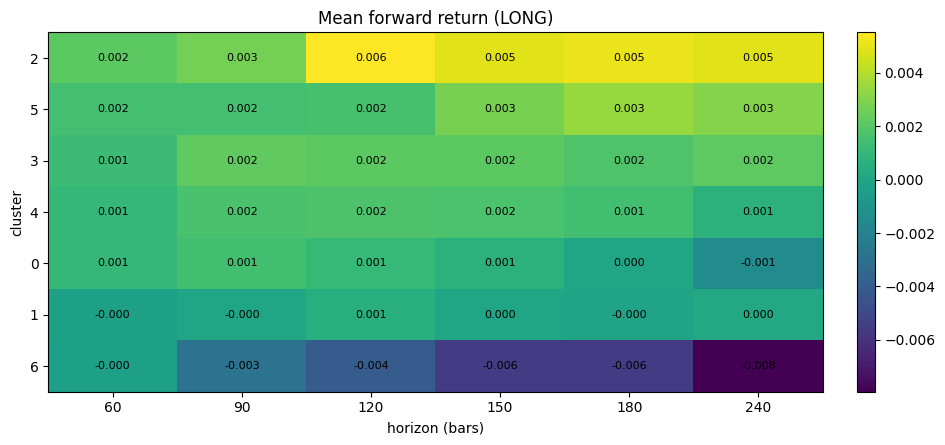

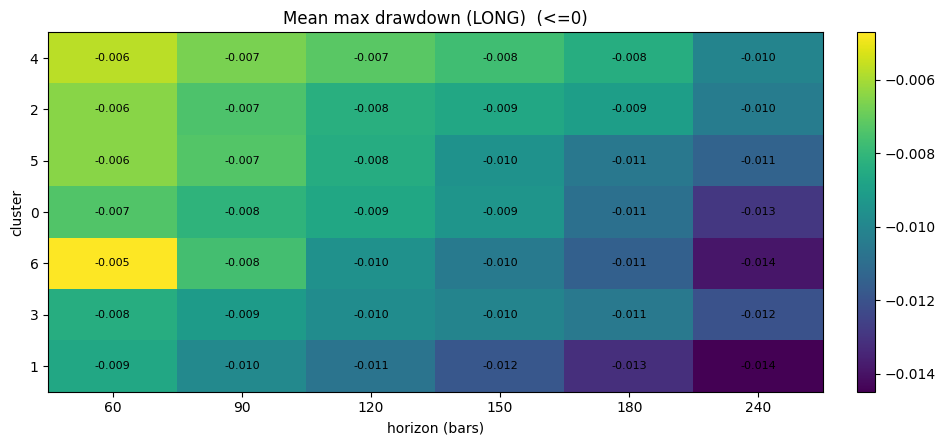

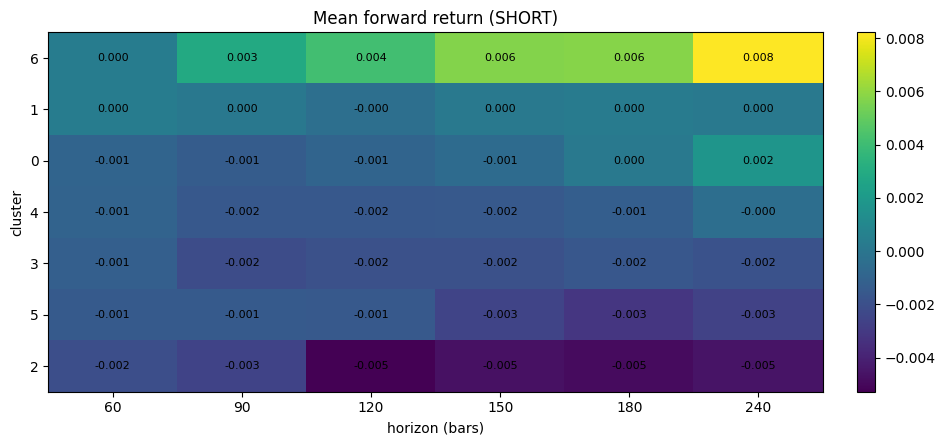

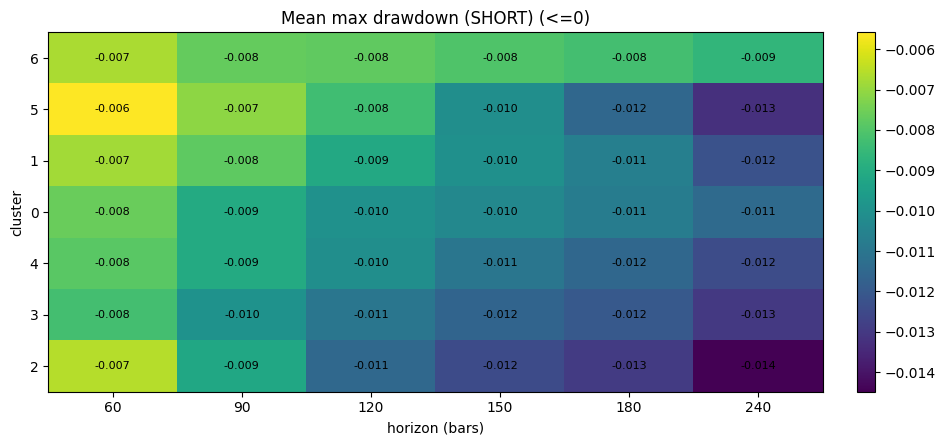

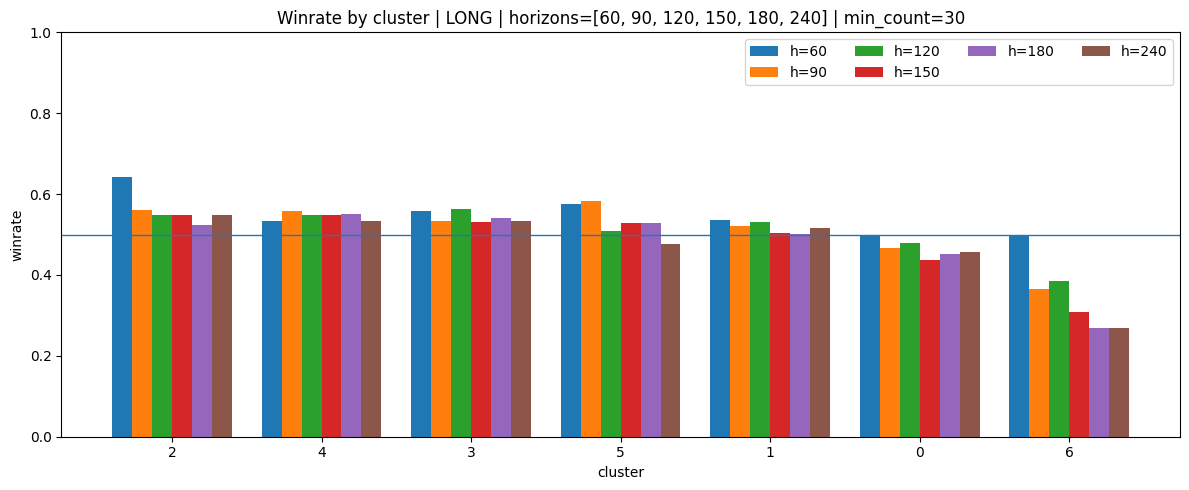

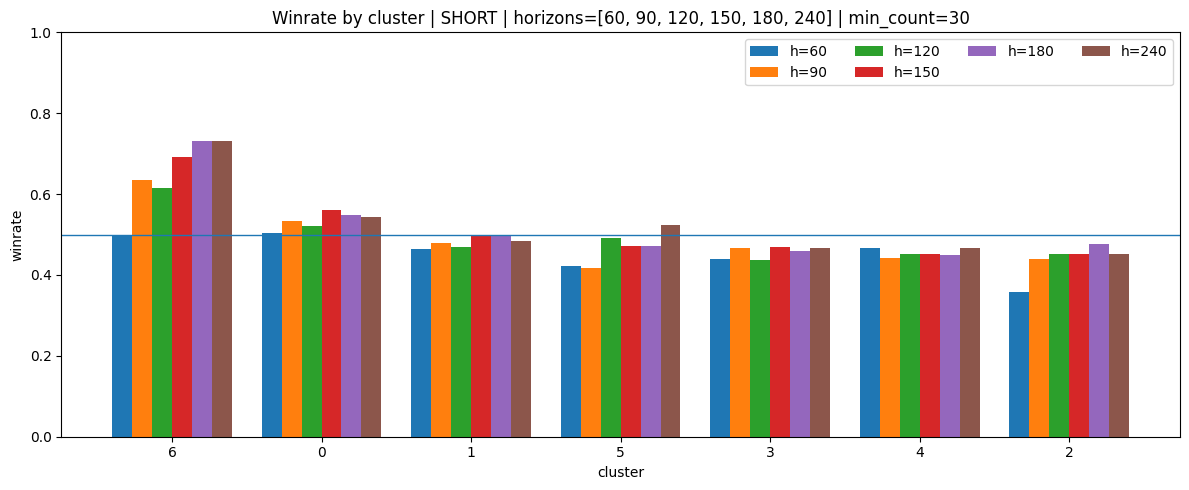

In [10]:
# df_prices: DataFrame с колонкой Close и тем же индексом, что и anomaly_indexes
# anomaly_indexes: индексы аномалий (int позиции или timestamps)
# sample_labels: кластер для каждой аномалии

from drive.MyDrive.stocks.duet.duet_class.pipeline.analyze_future_effect import (
    ClusterFutureEffect,
    FutureEffectConfig,
    ClusterFutureEffectViz,
)

HORIZONS = (60, 90, 120, 150, 180, 240)

e = ClusterFutureEffect(FutureEffectConfig(horizons=HORIZONS, price_col="Close"))
# ЕСЛИ ДАВАЛИ БУДУЩЕЕ, ТО ОБЯЗАТЕЛЬНО СМЕЩАЕМ ТОЧКУ ВХОДА-------------\/
out = e.evaluate(df_with_pred, anomaly_indx, sample_labels, open_price_shift=20)

per_event = out["per_event"]   # детально по каждой аномалии и горизонту
summary = out["summary"]       # агрегаты по кластеру и горизонту
# print(summary.sort_values(["h", "ret_long_mean"], ascending=[True, False]).head(20))

viz = ClusterFutureEffectViz()
viz.plot_heatmaps(summary)

viz.plot_winrate_bars(
    summary,
    horizons=HORIZONS,
    side="long",
    min_count=30,
    top_k=20,
    sort_by="mean",
)
viz.plot_winrate_bars(
    summary,
    horizons=HORIZONS,
    side="short",
    min_count=30,
    top_k=20,
    sort_by="mean",
)

/usr/local/lib/python3.12/dist-packages/mplfinance/plotting.py:476: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


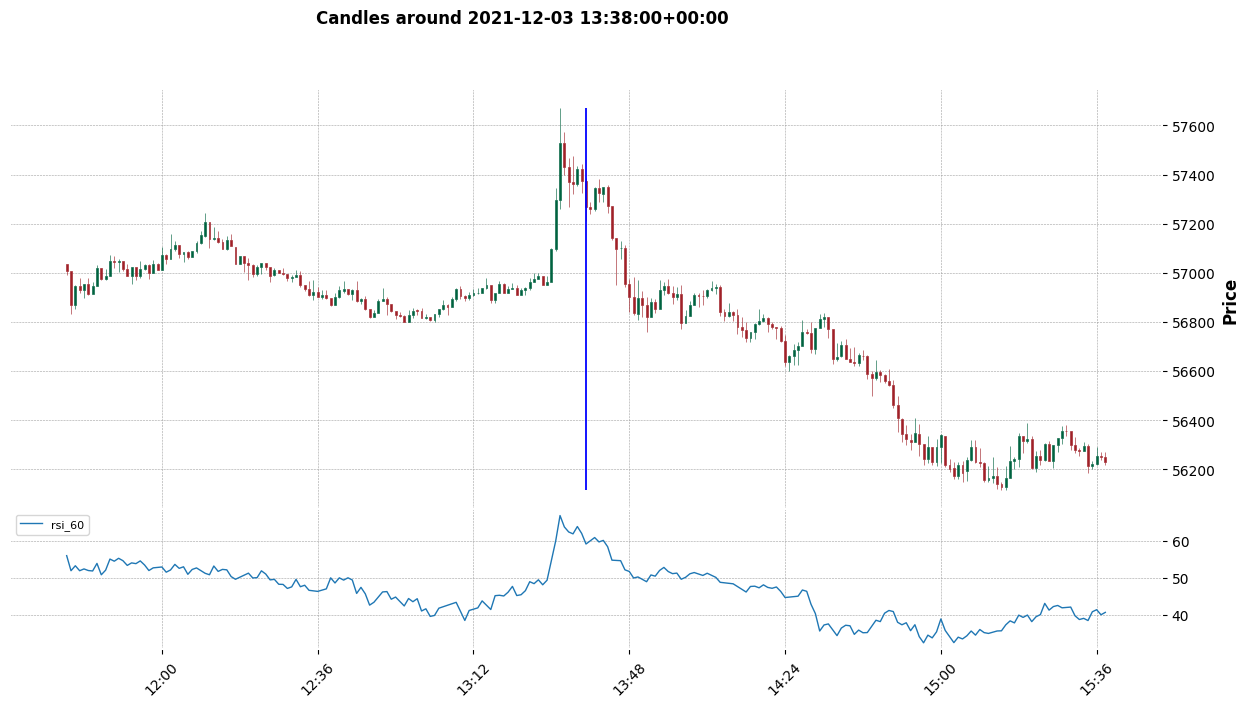

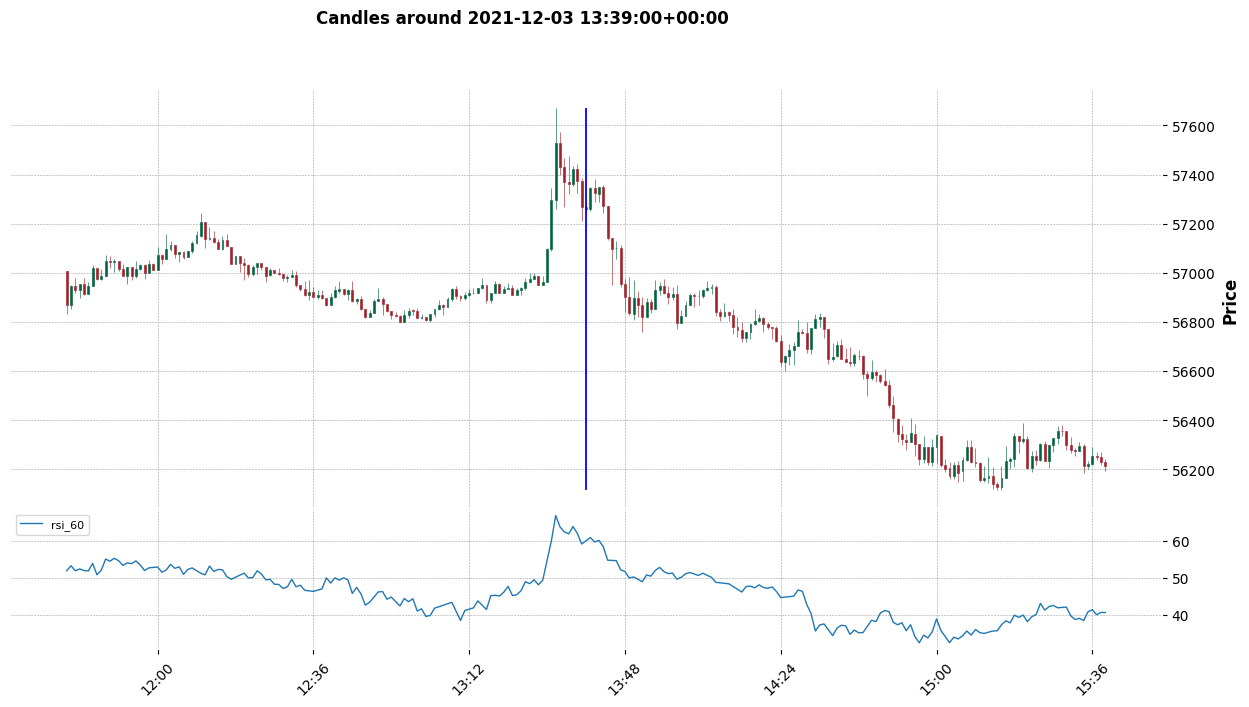

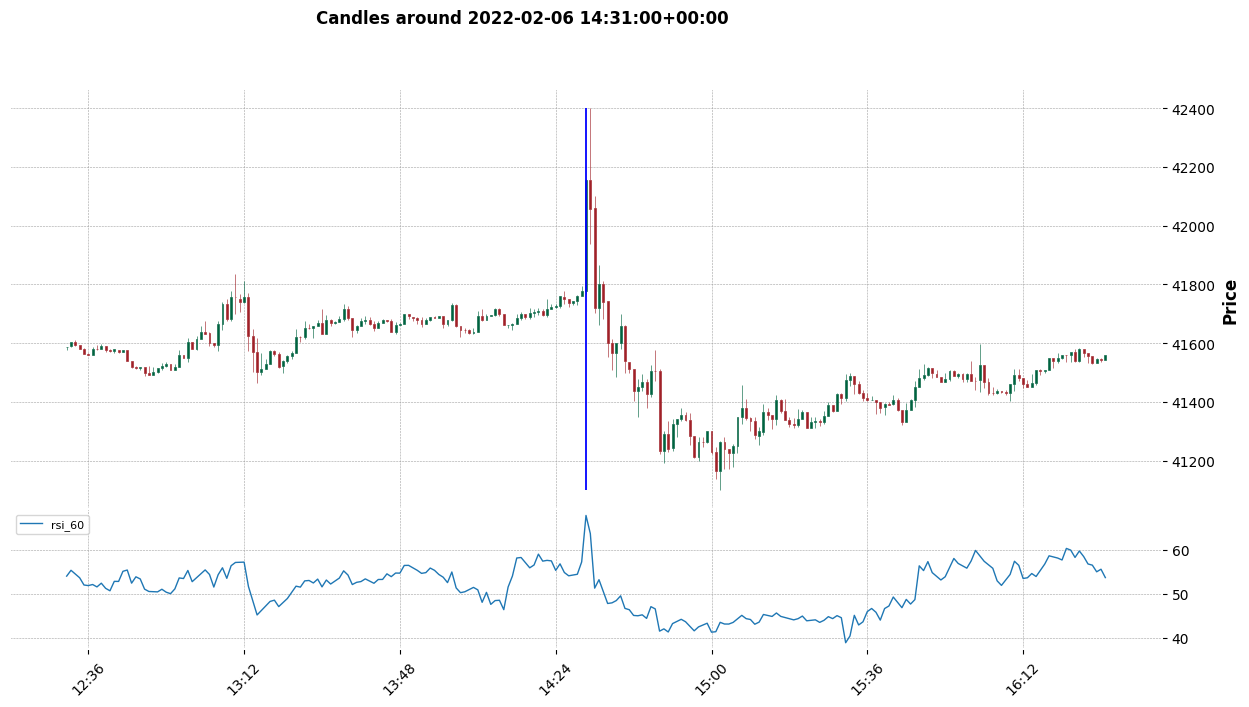

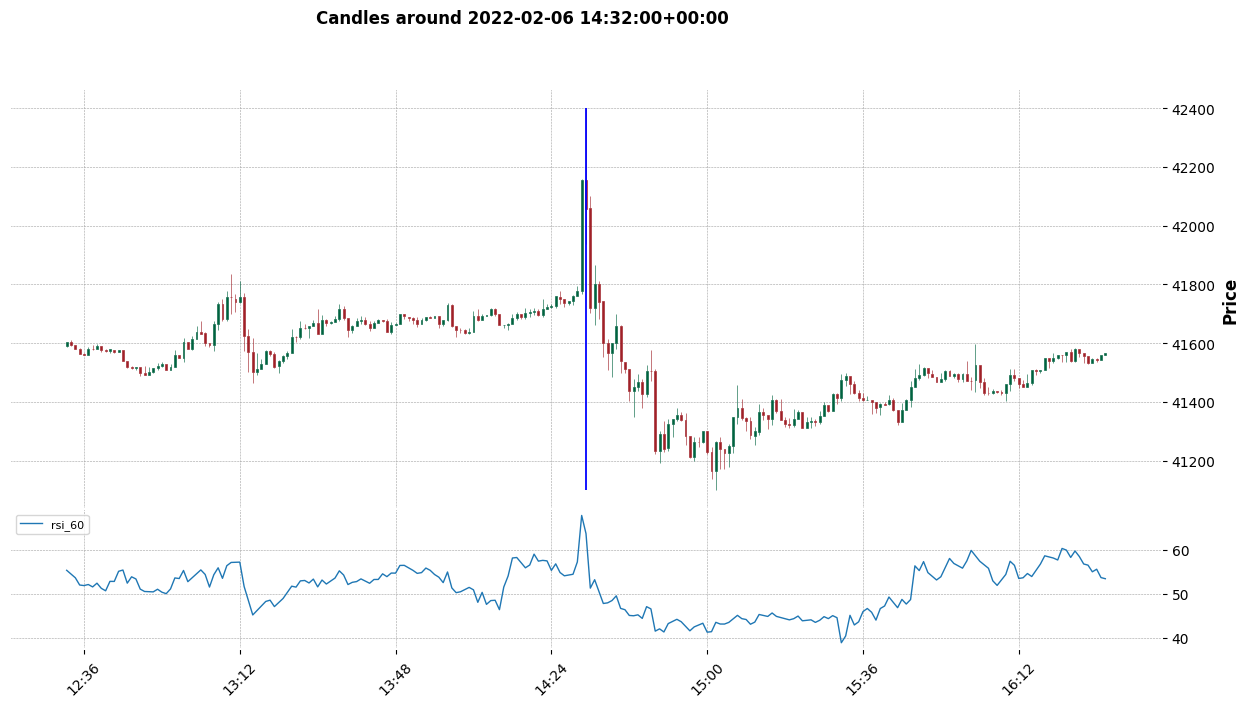

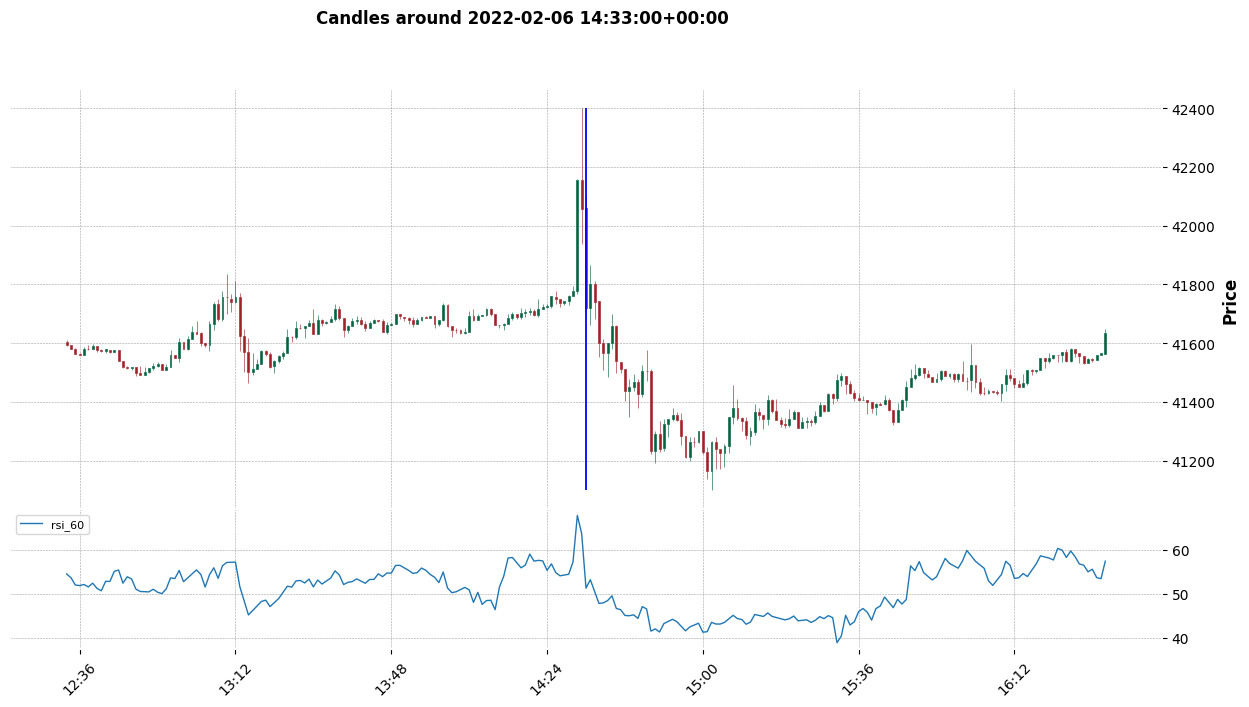

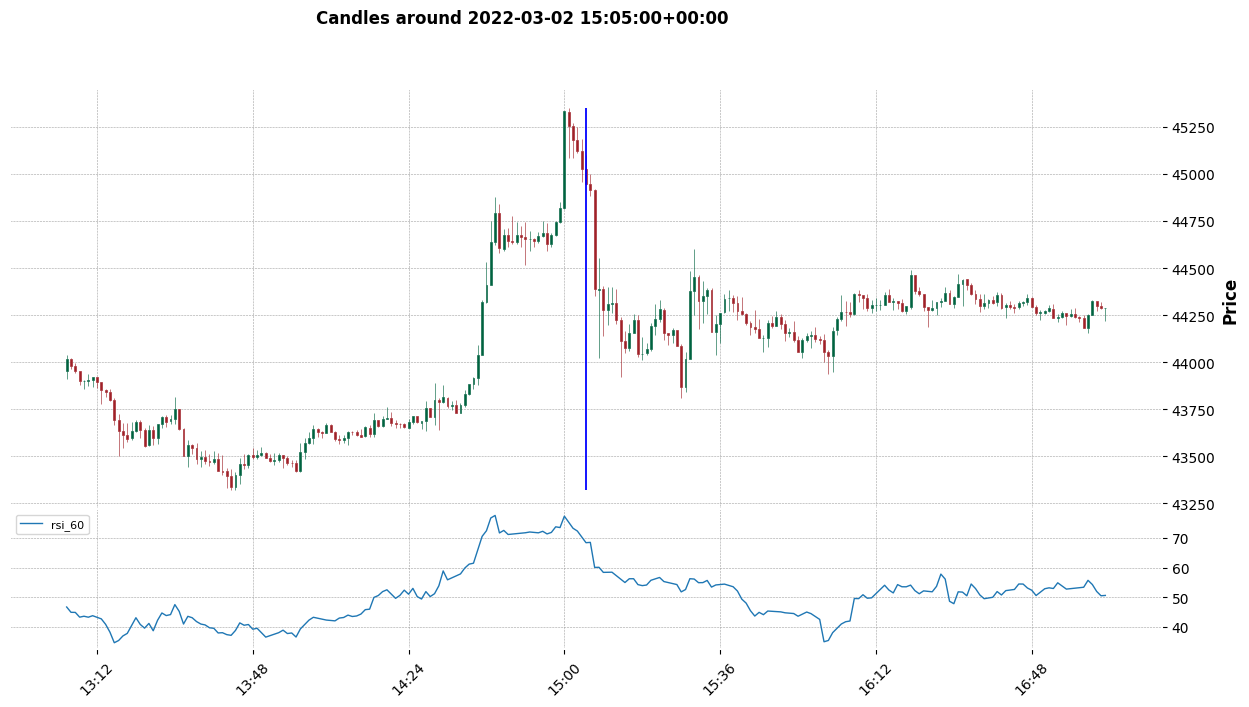

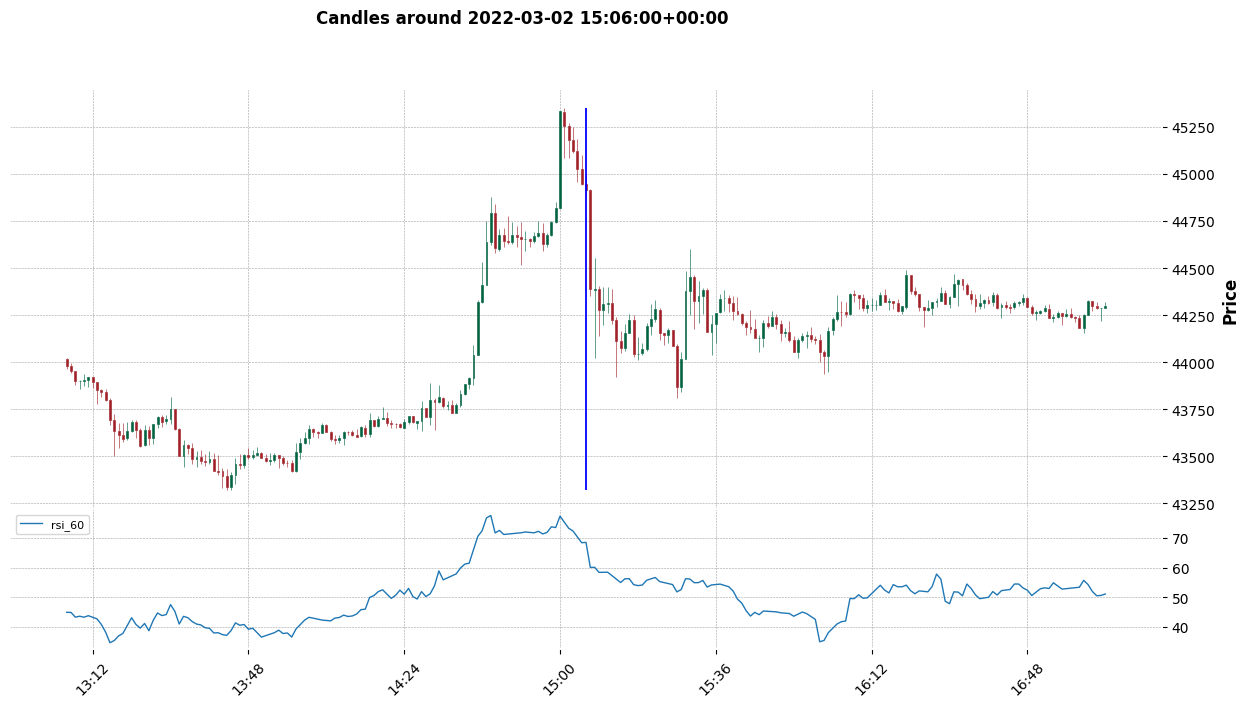

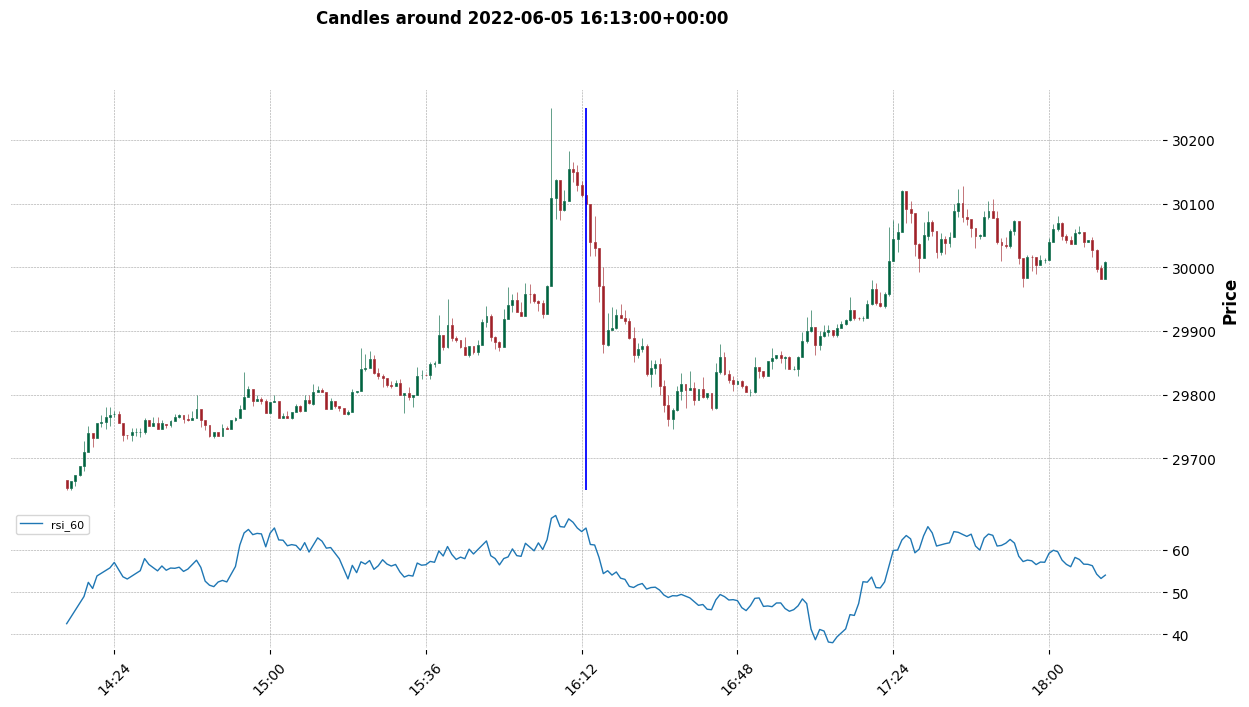

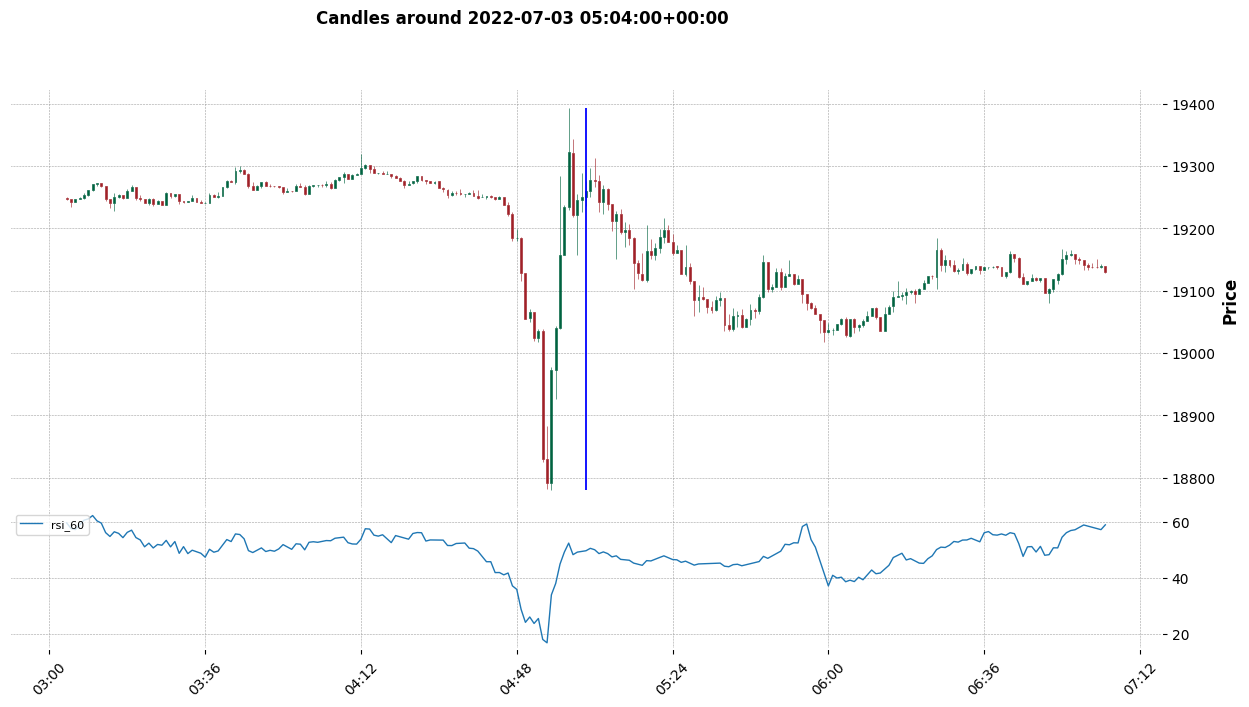

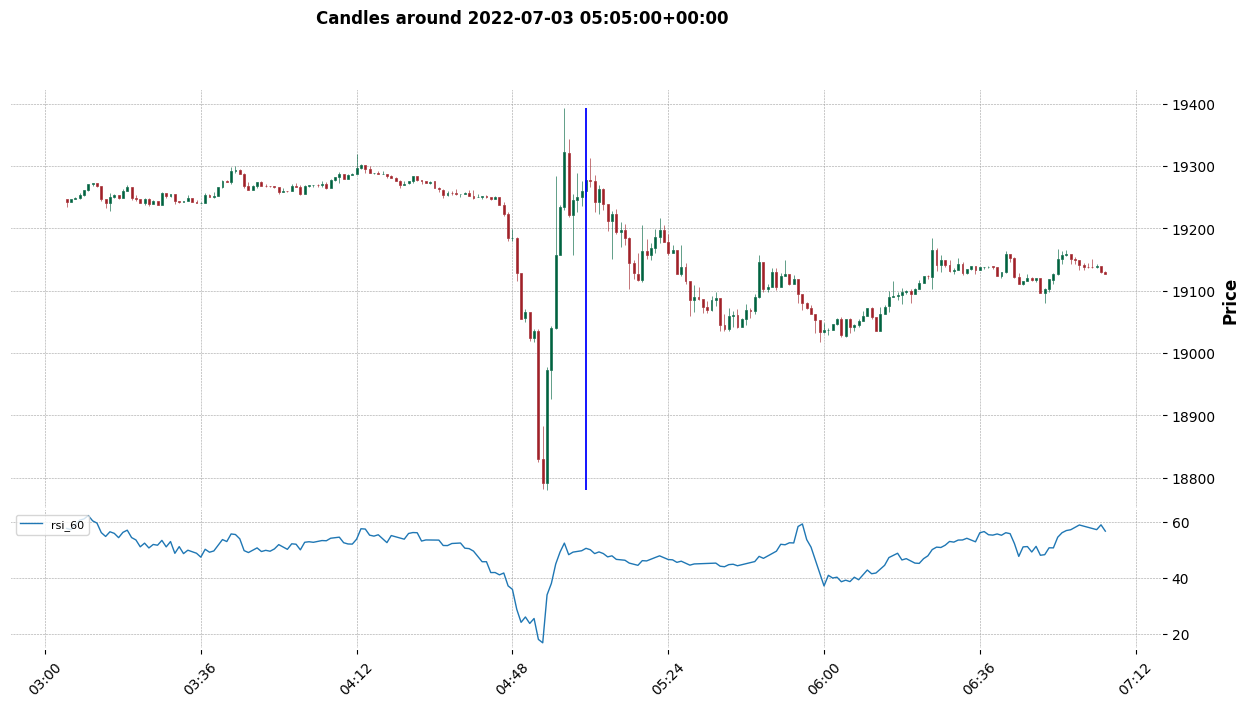

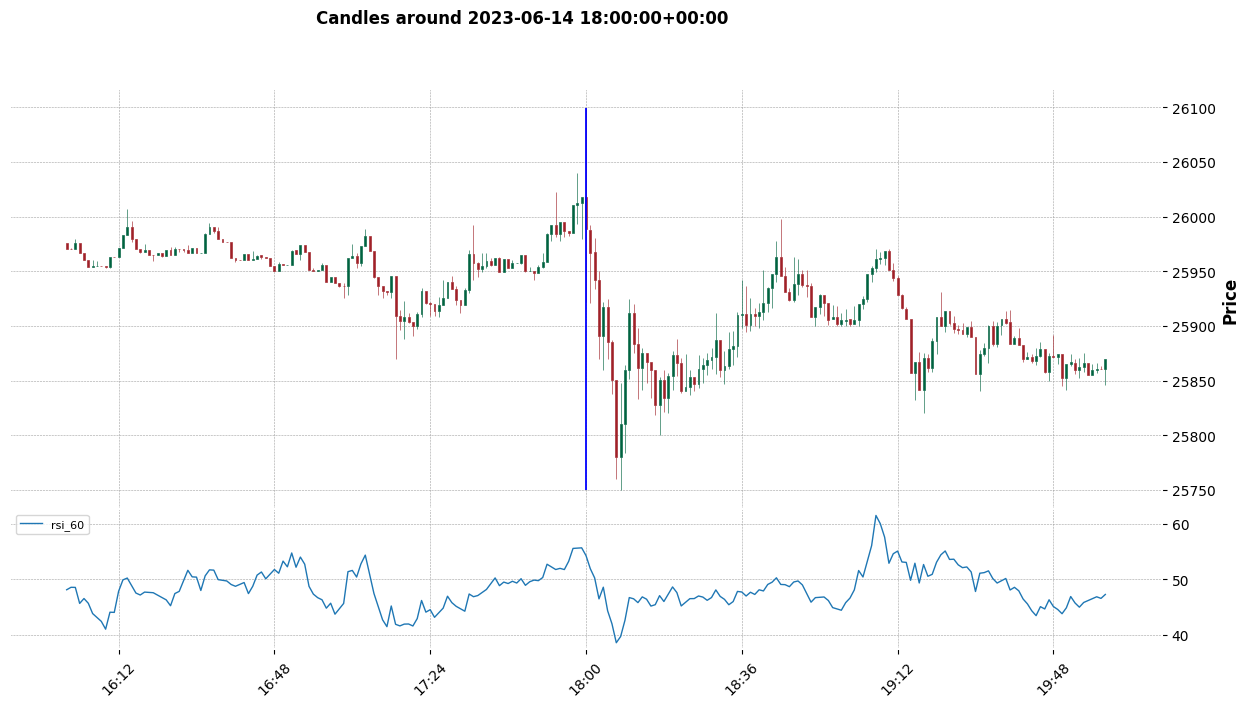

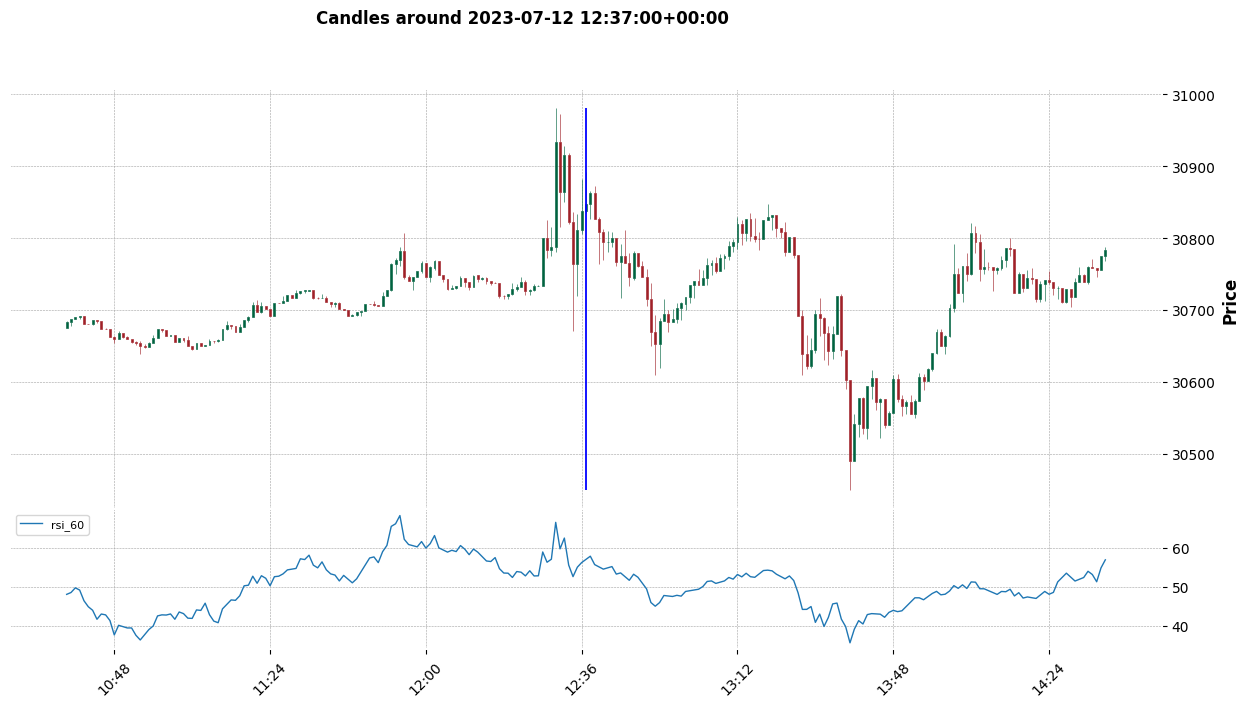

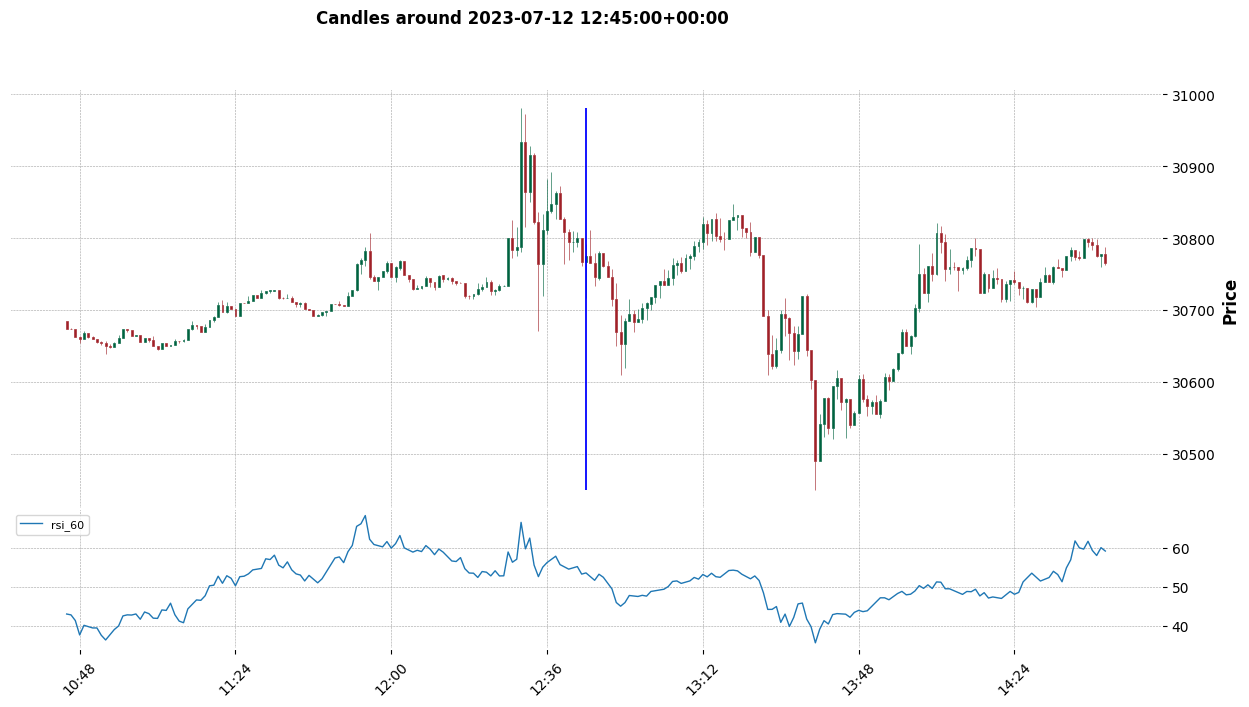

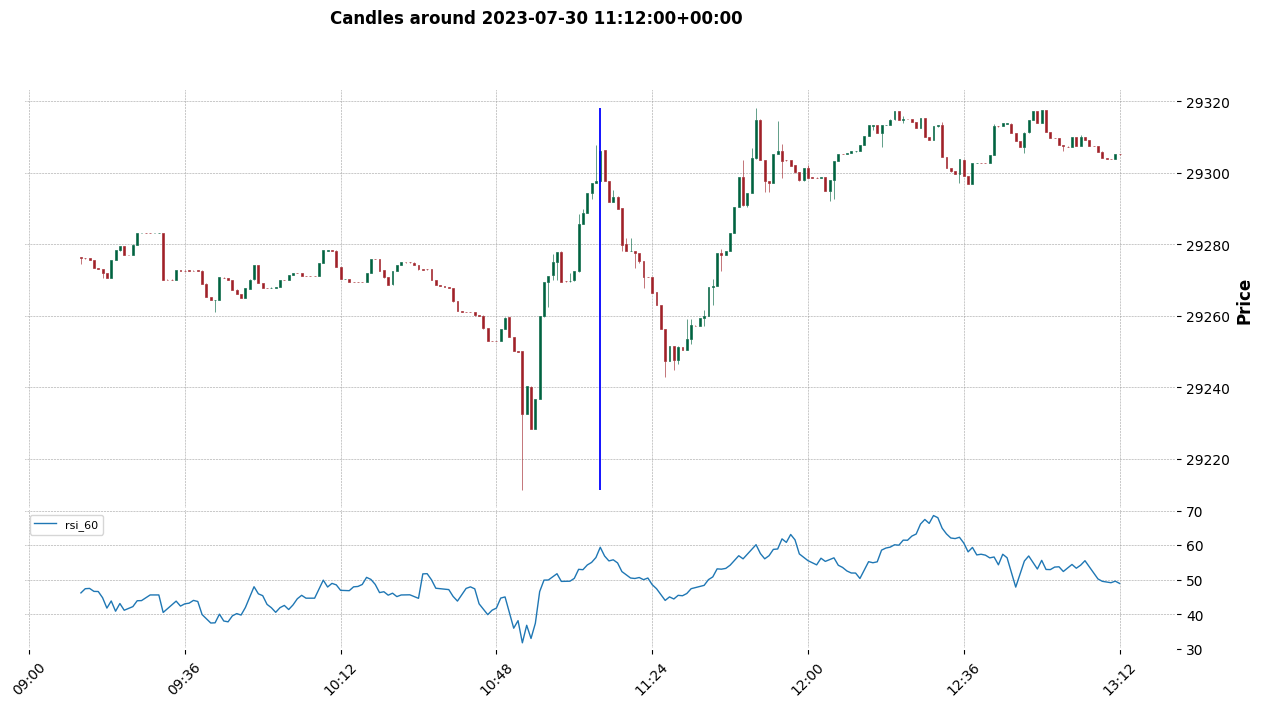

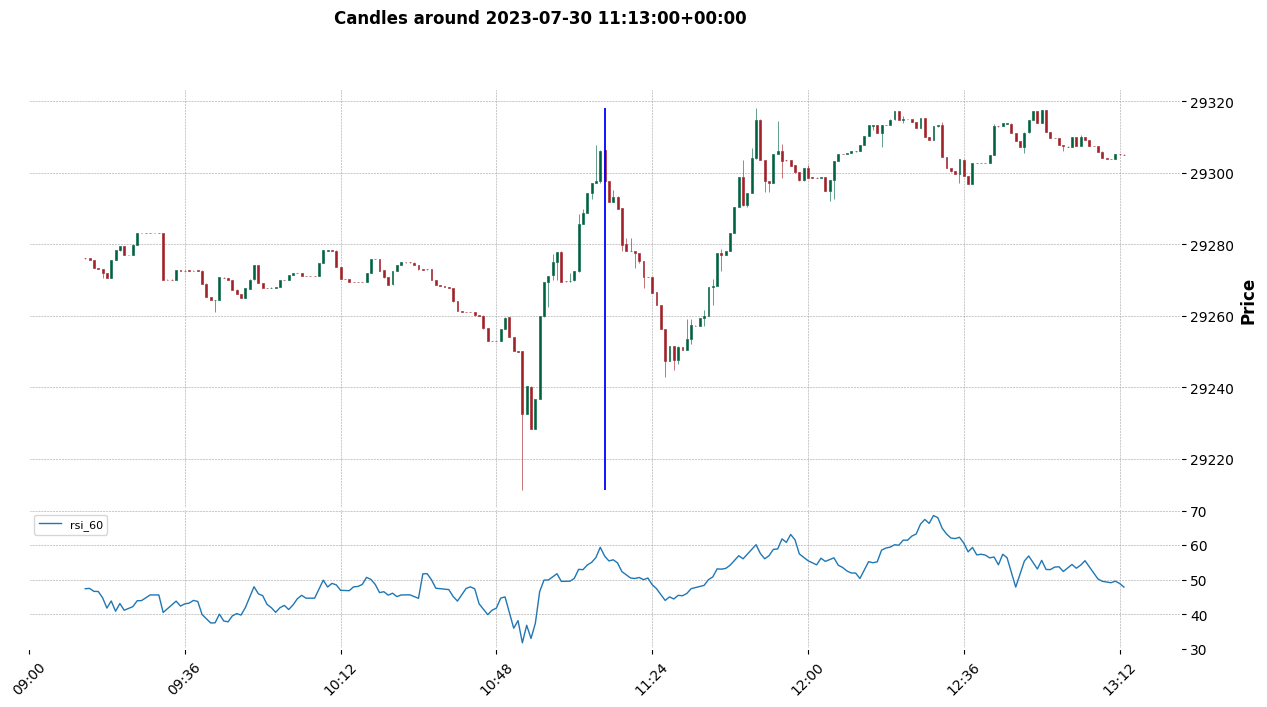

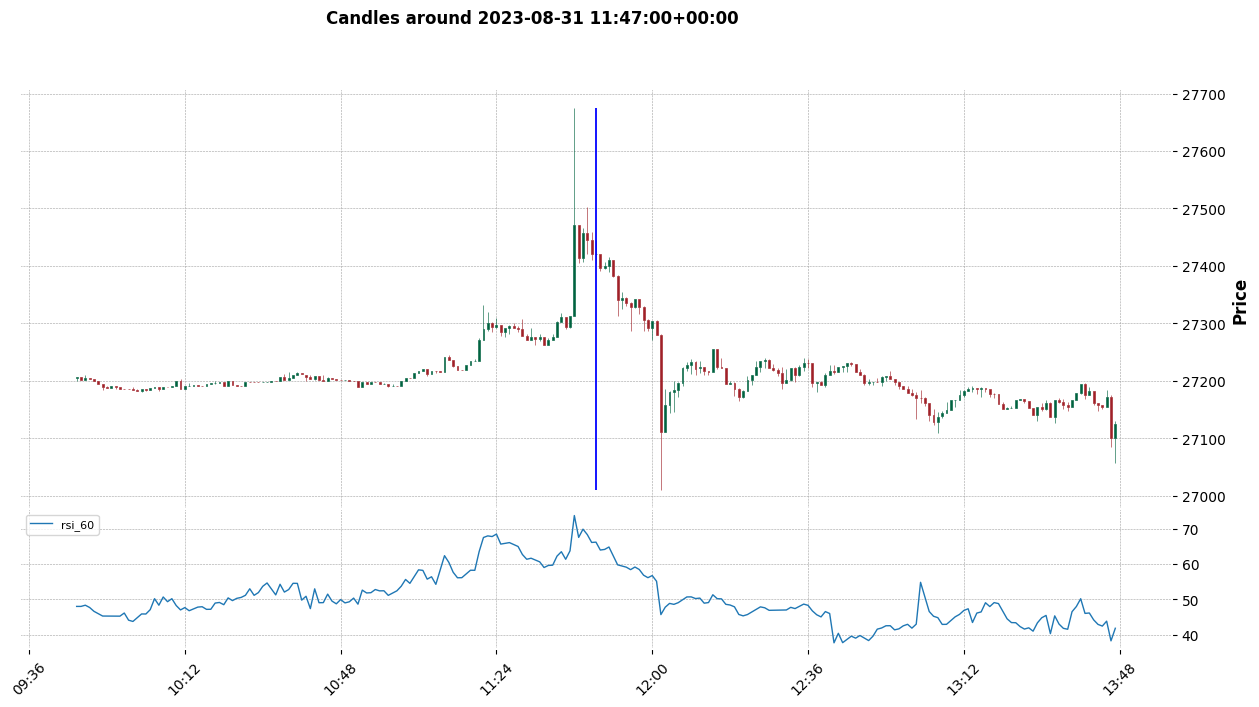

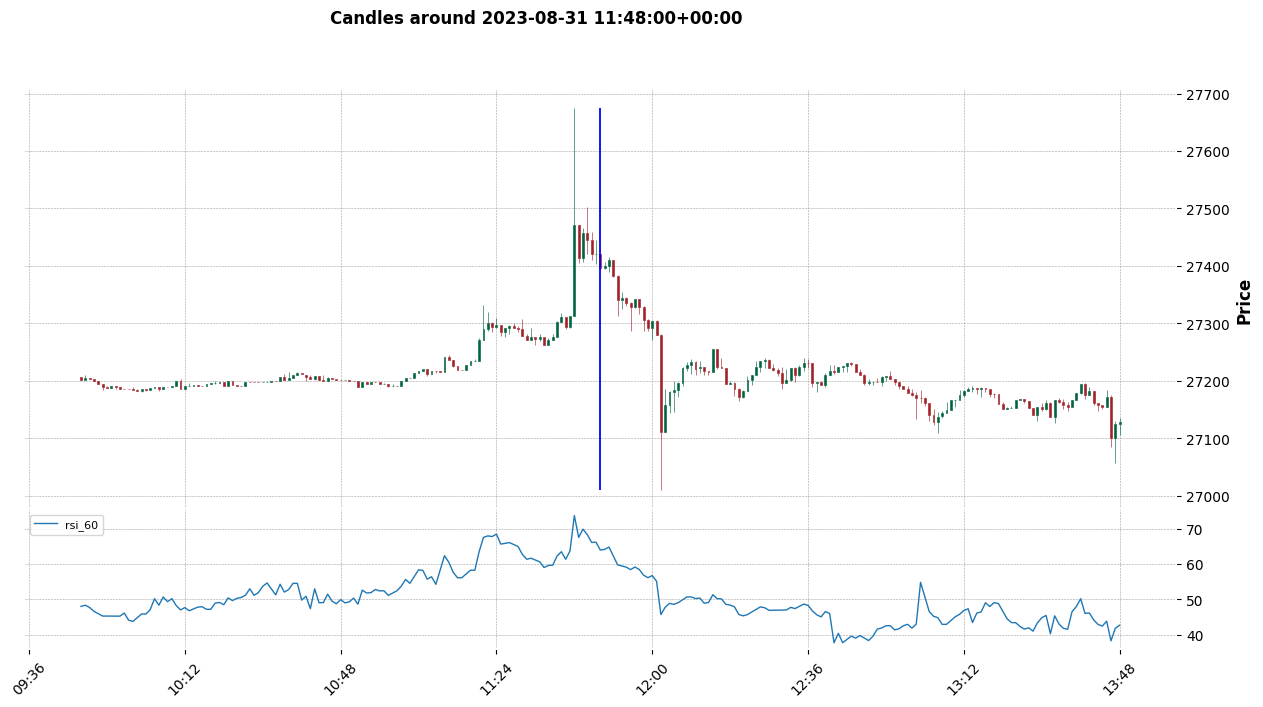

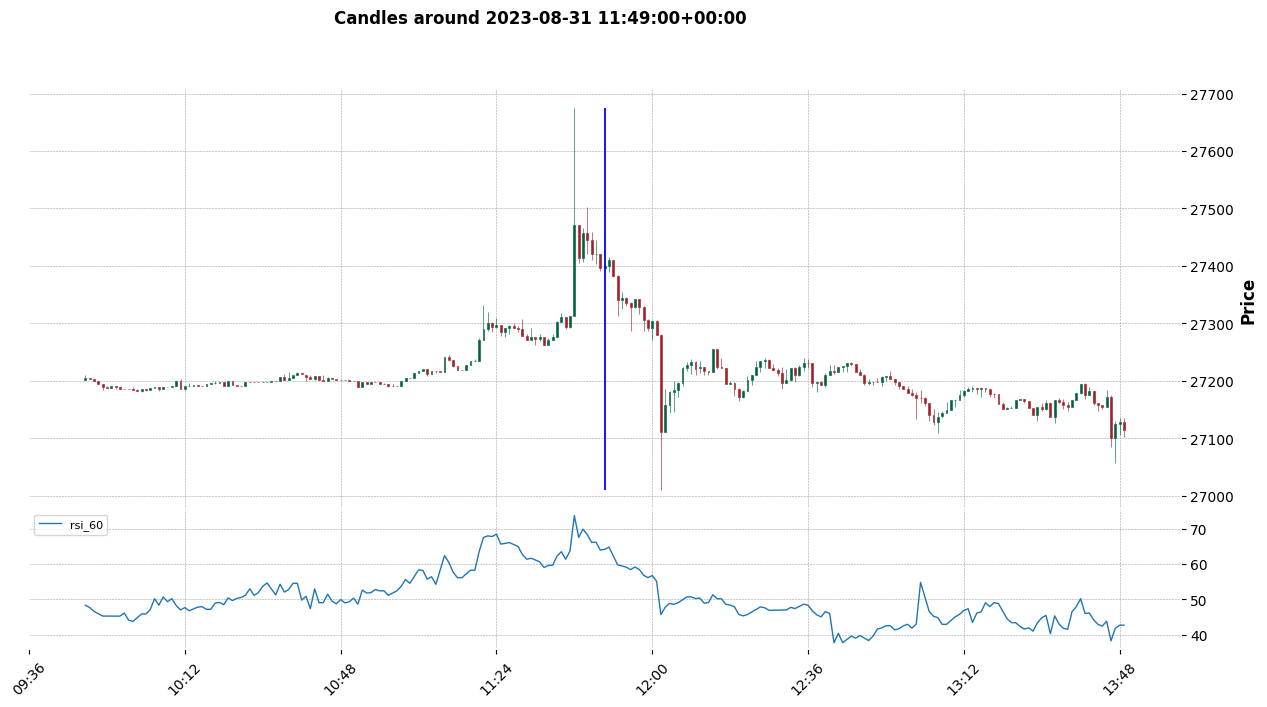

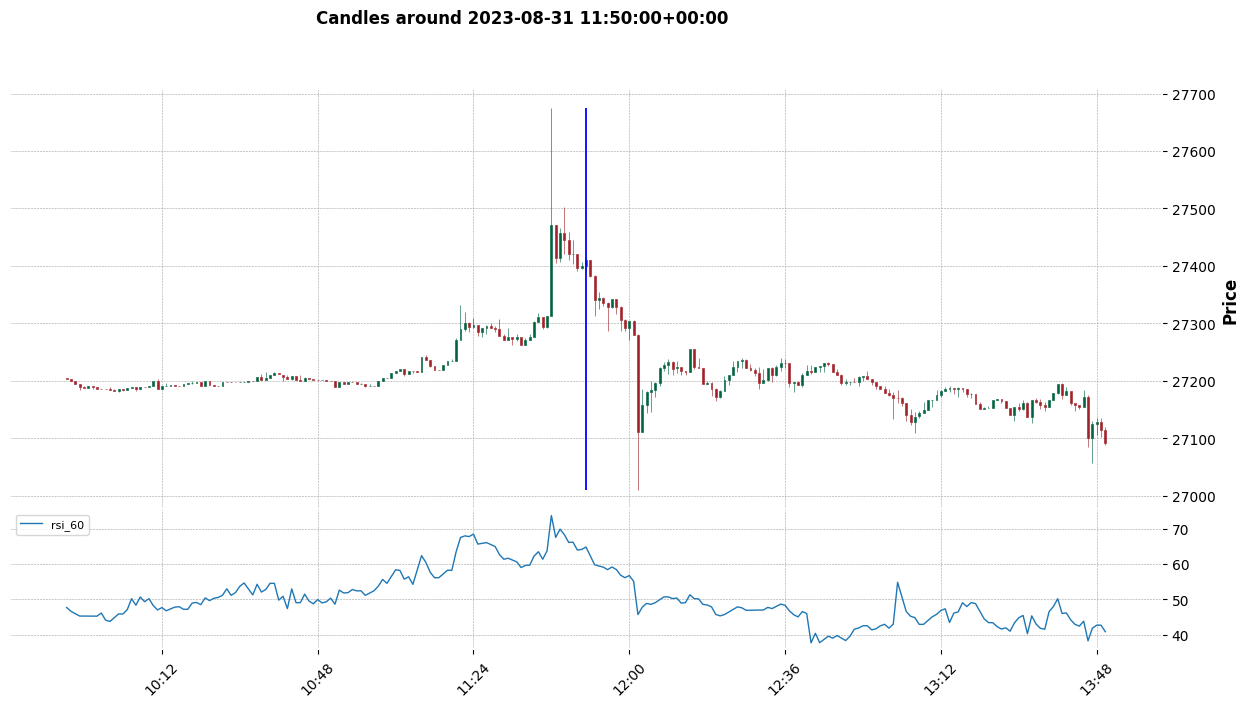

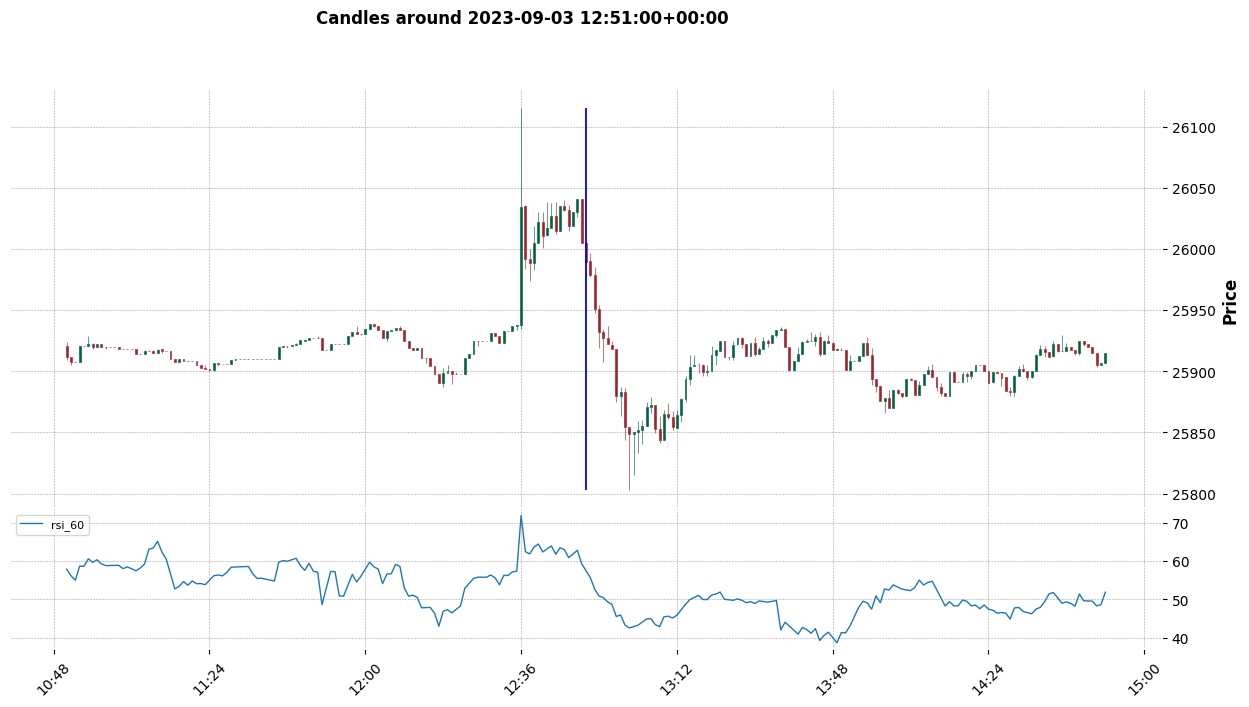

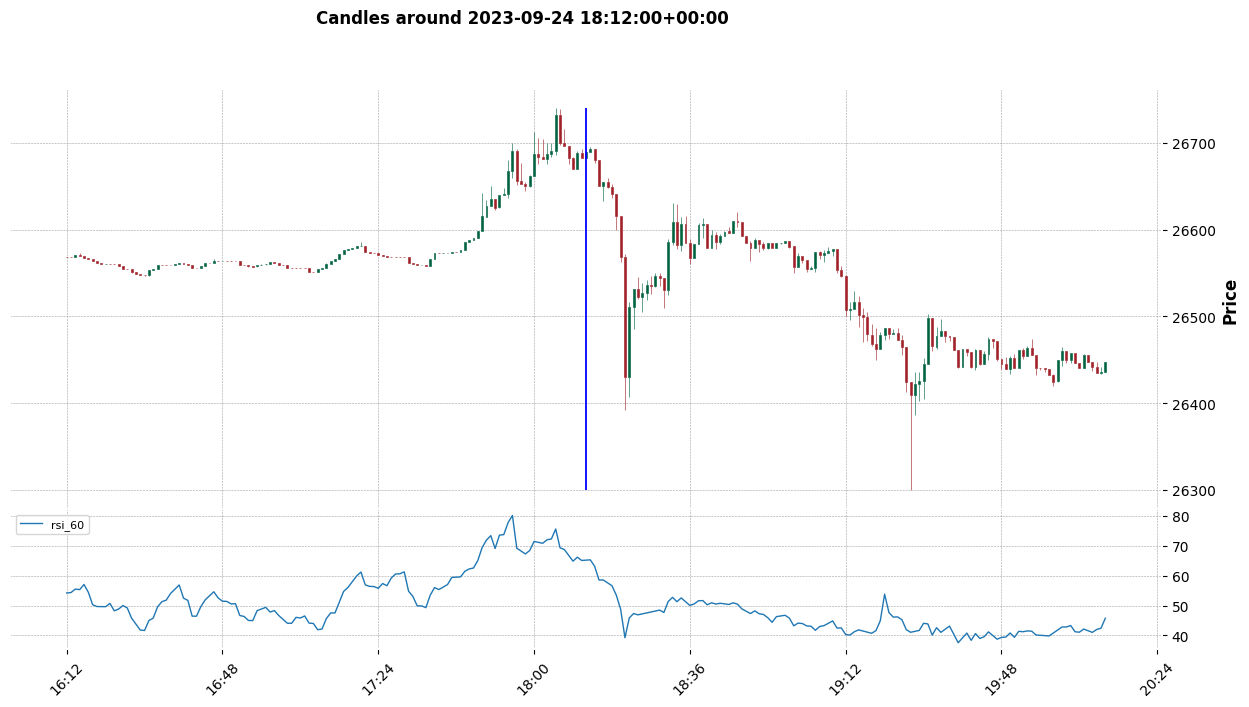

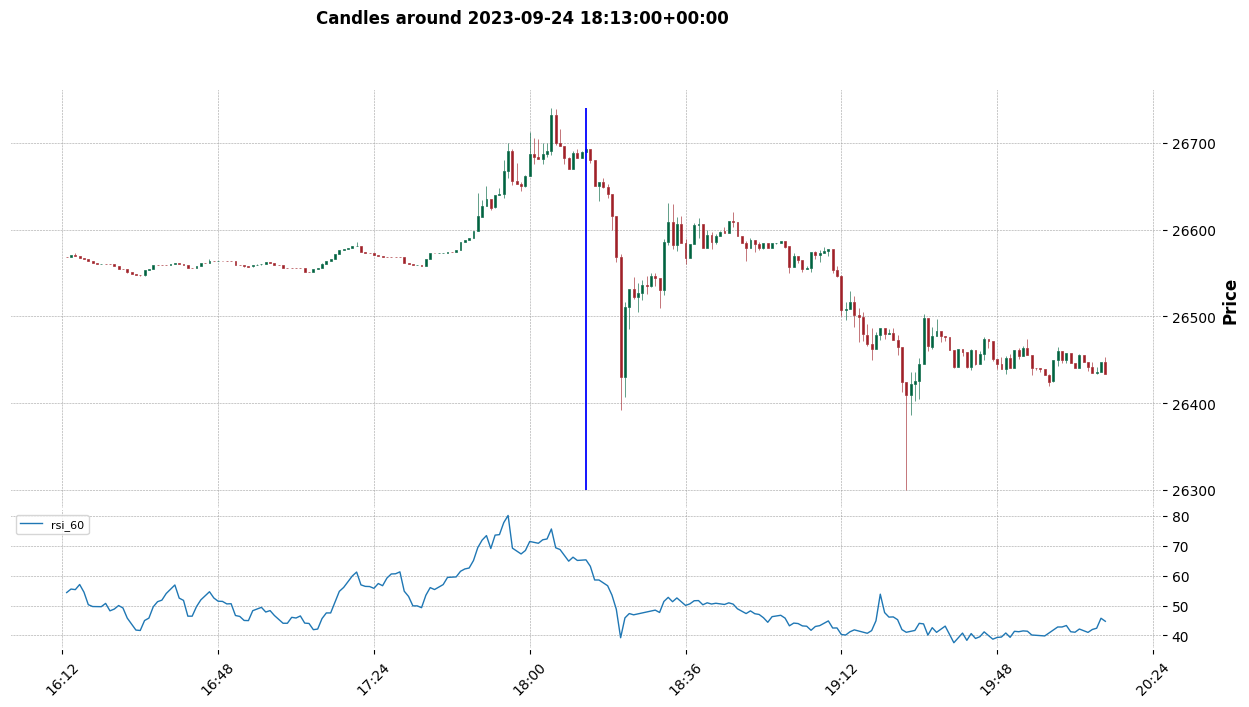

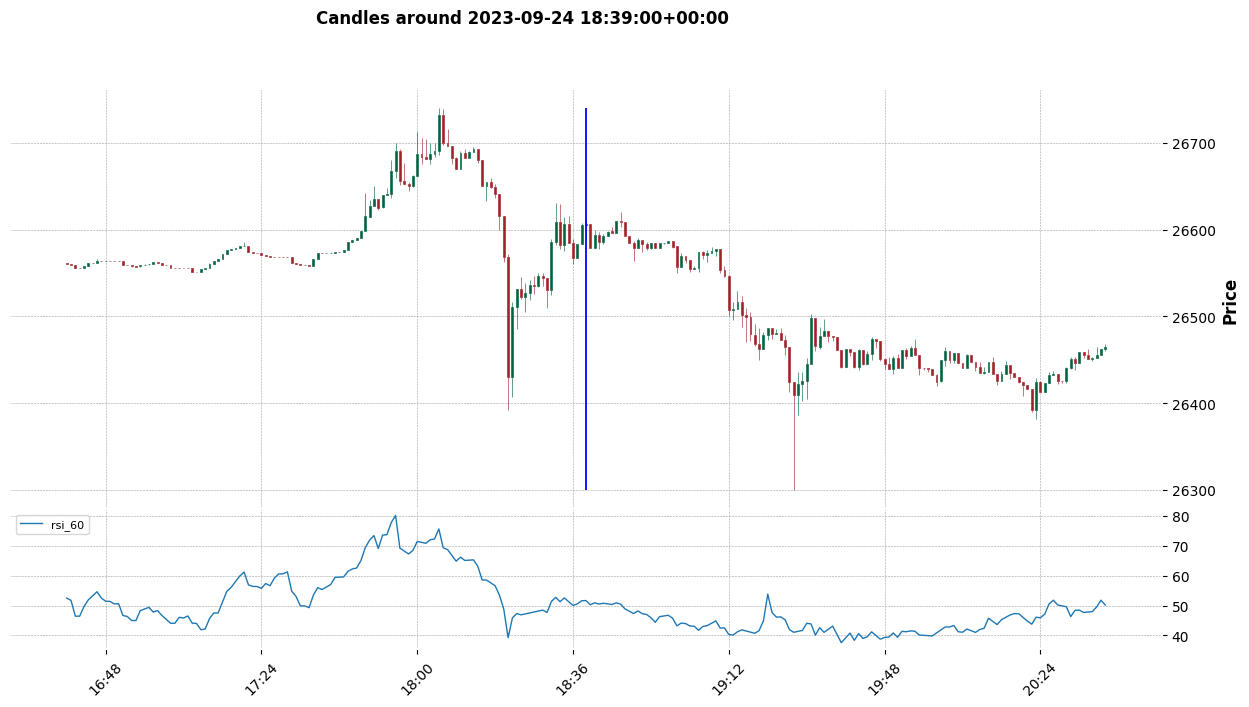

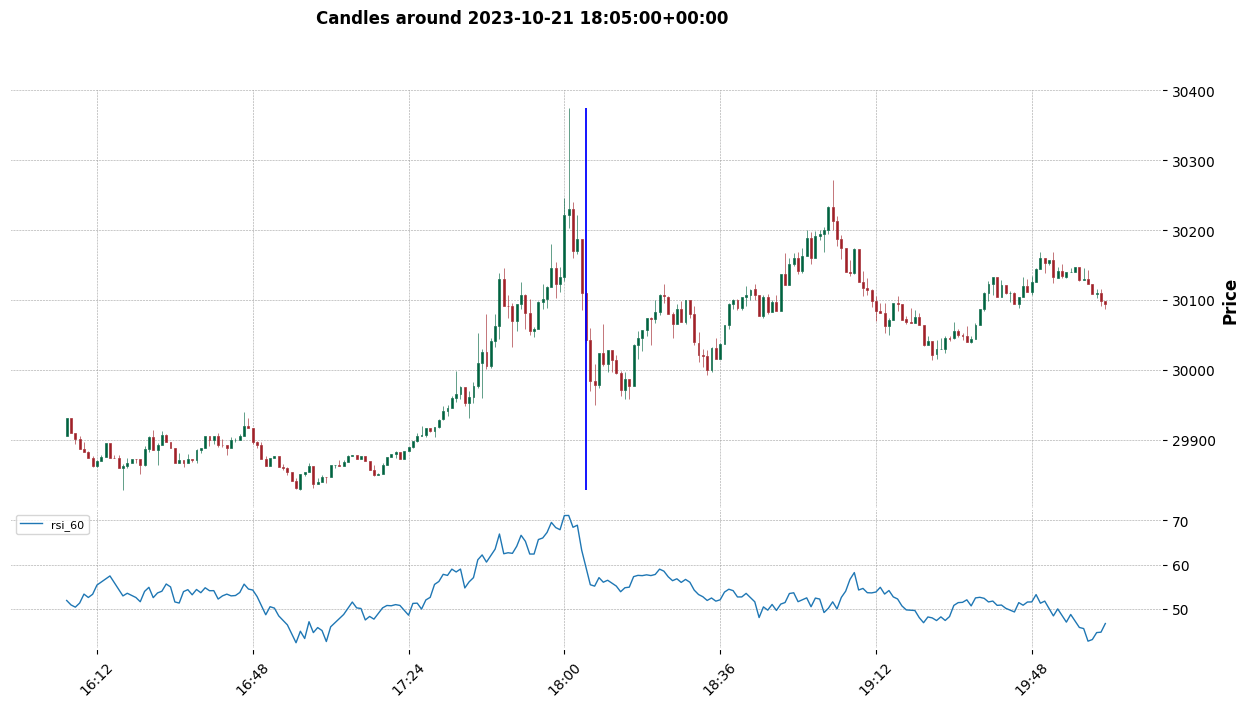

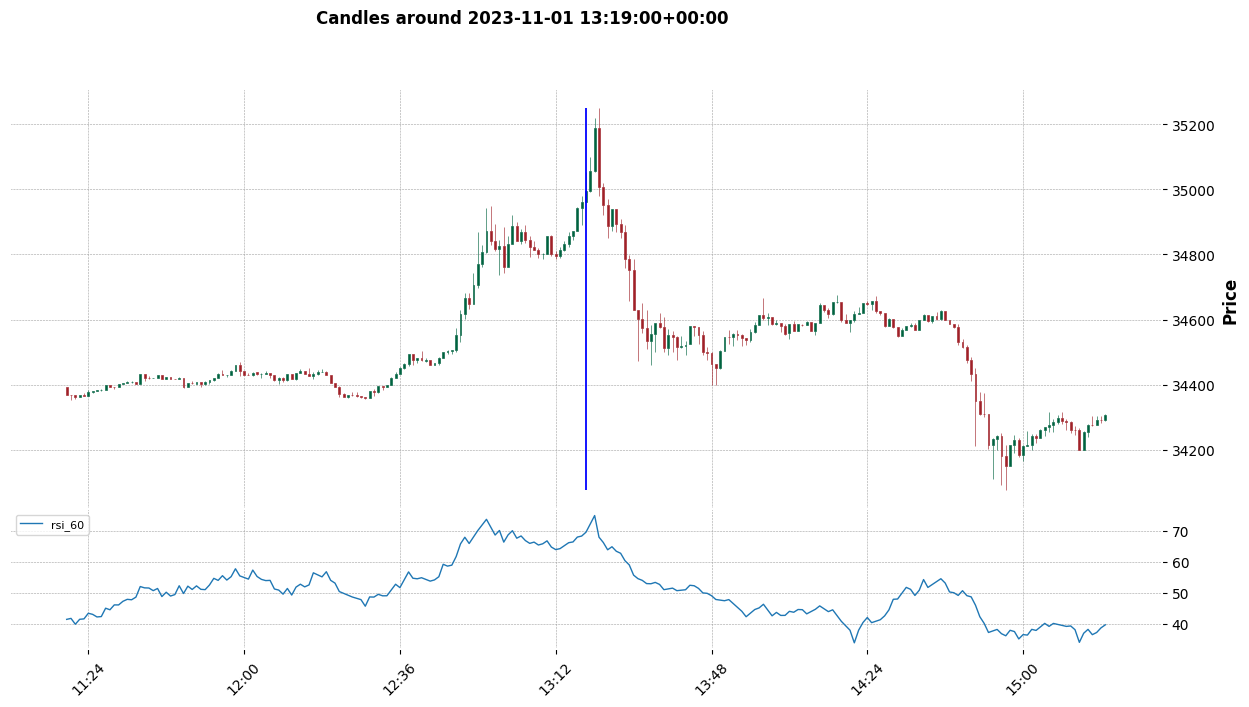

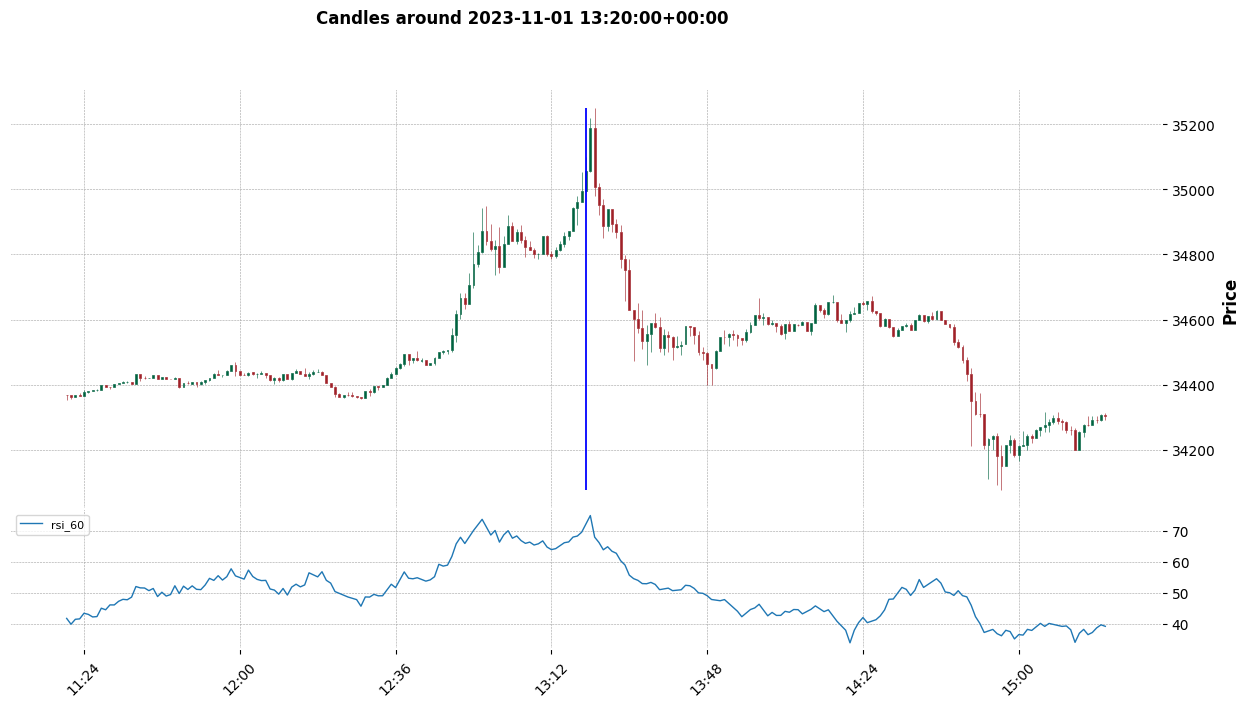

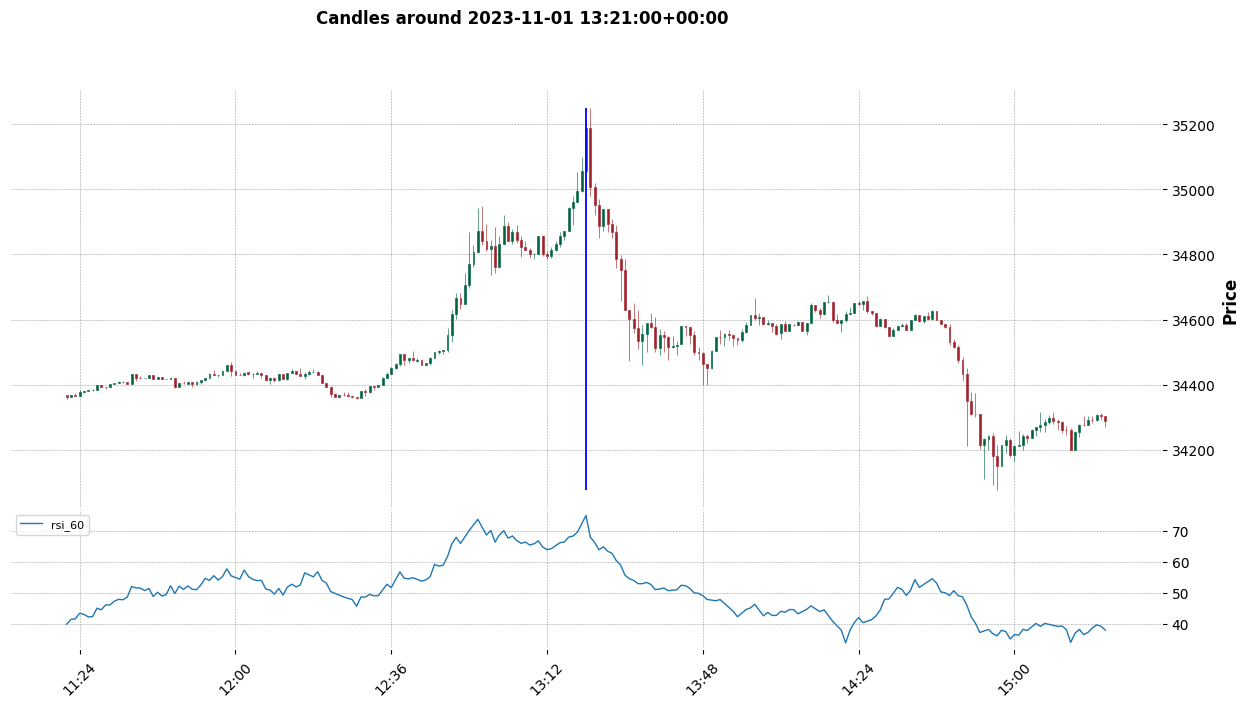

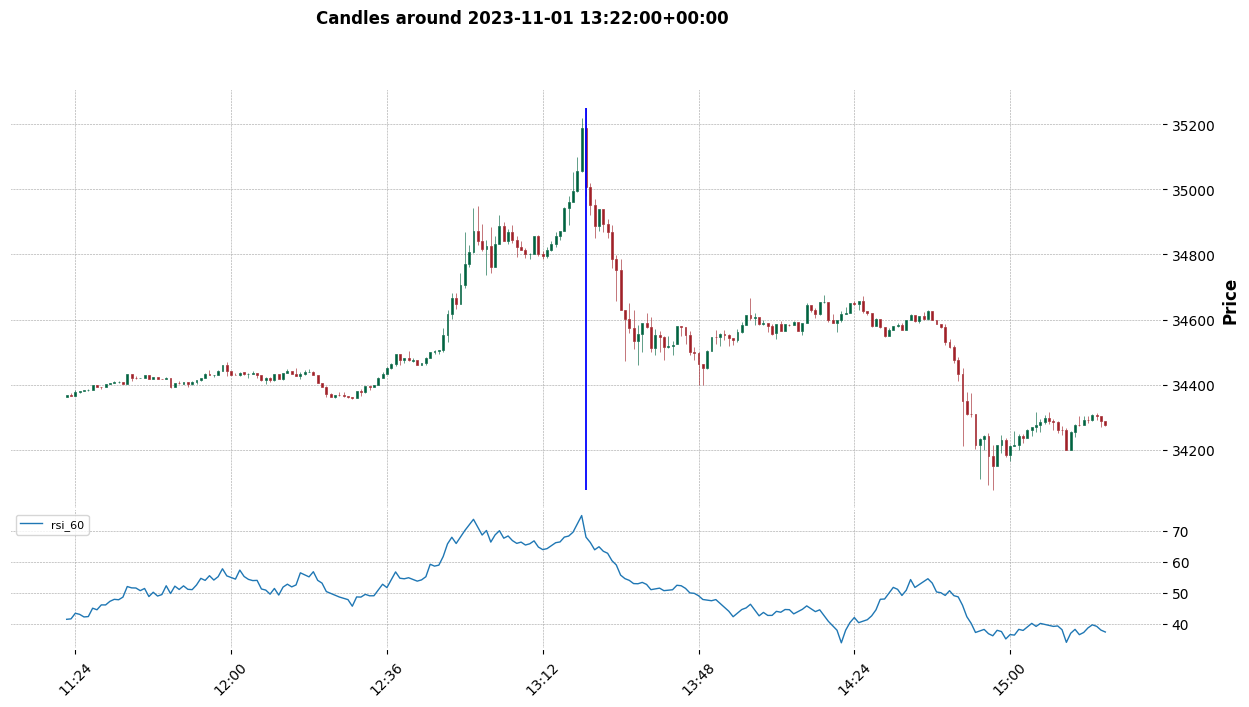

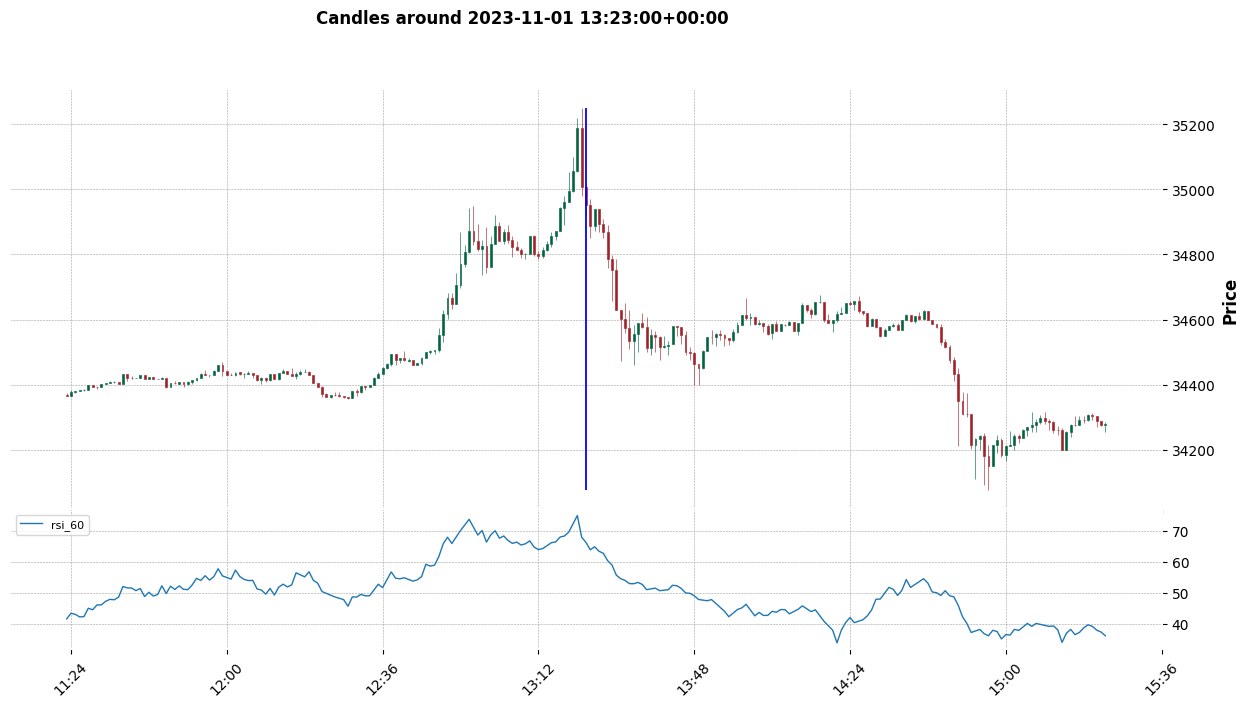

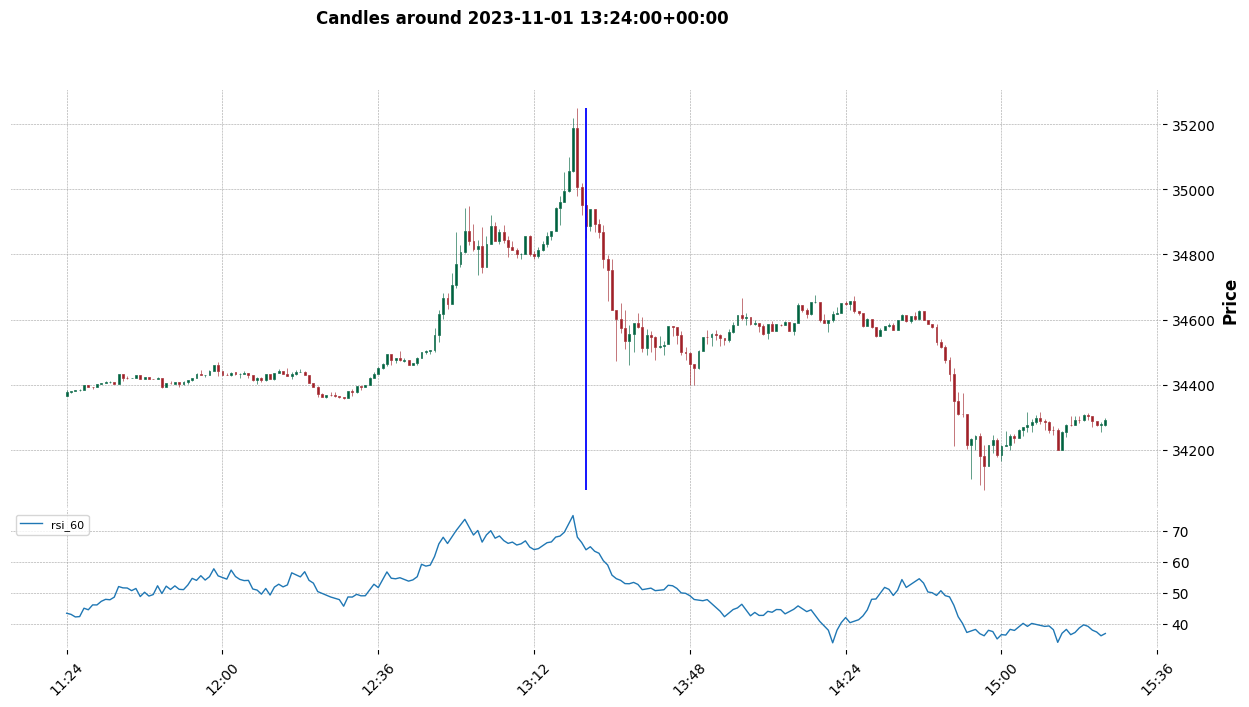

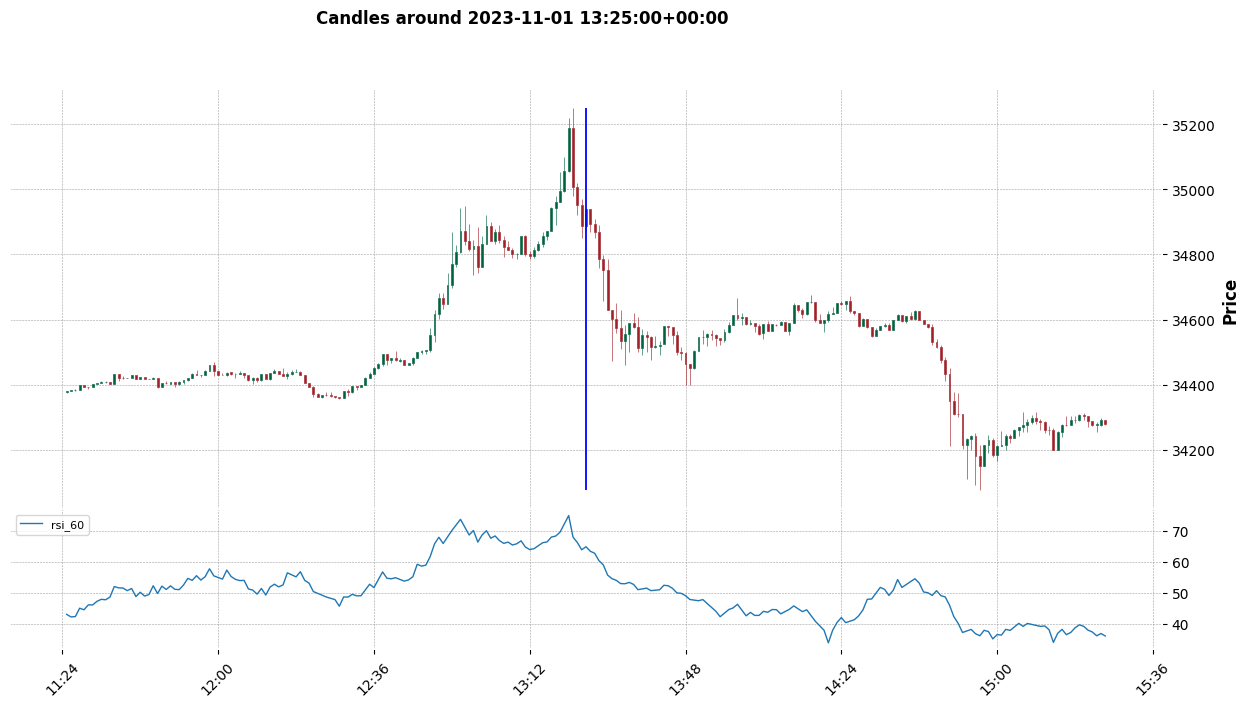

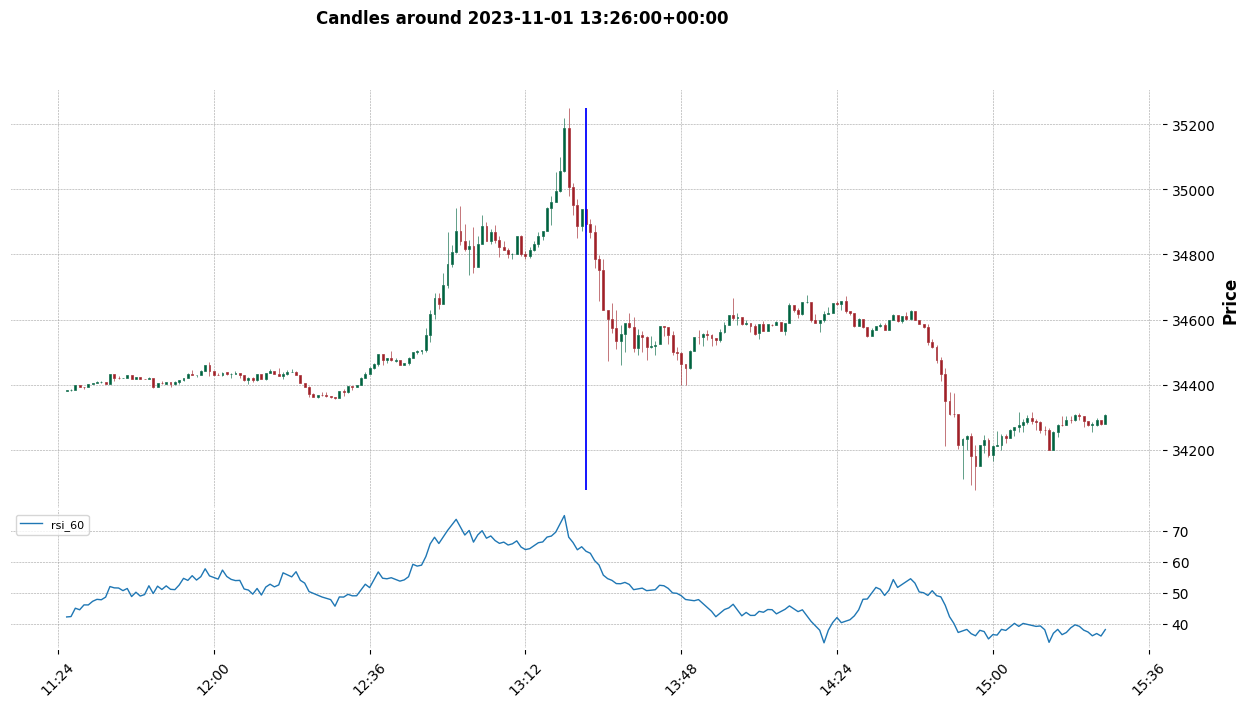

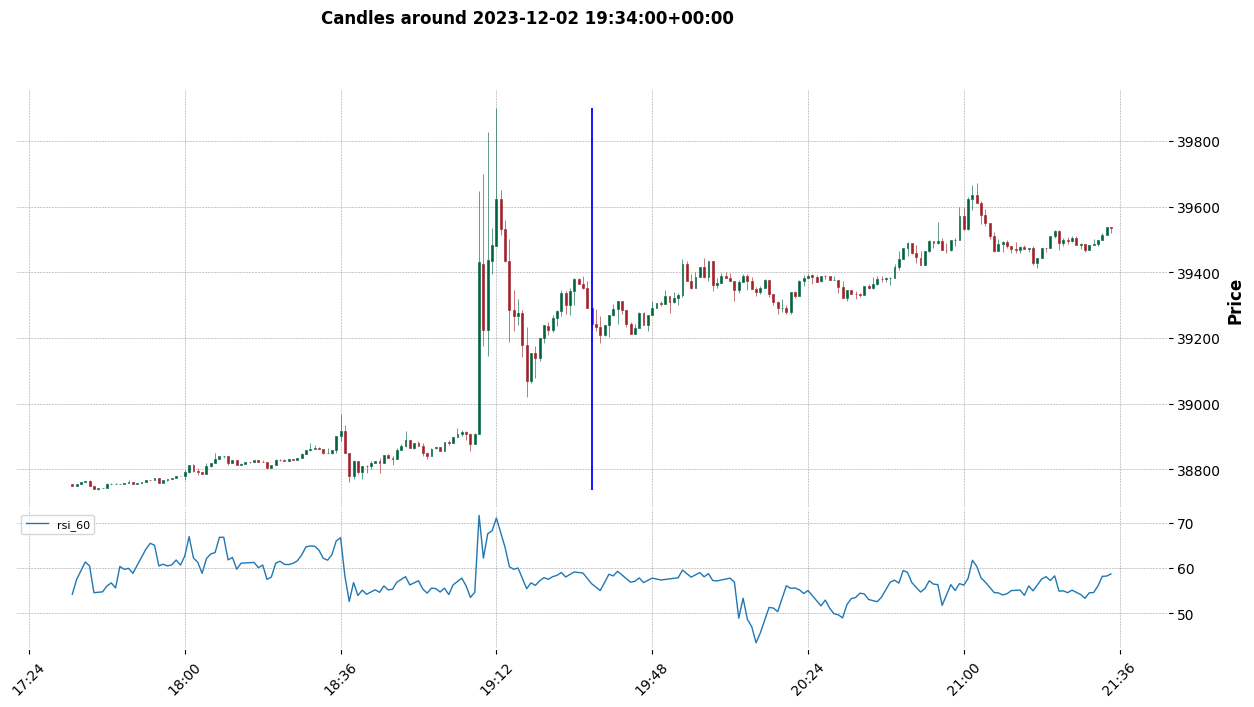

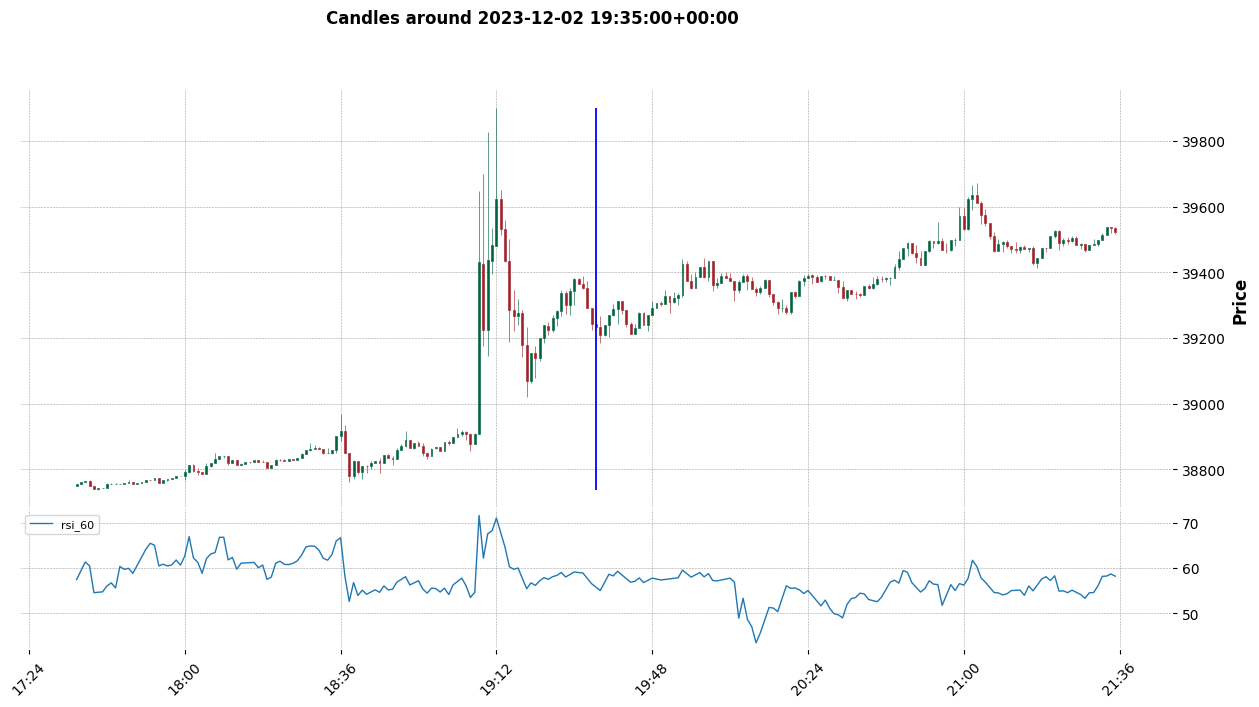

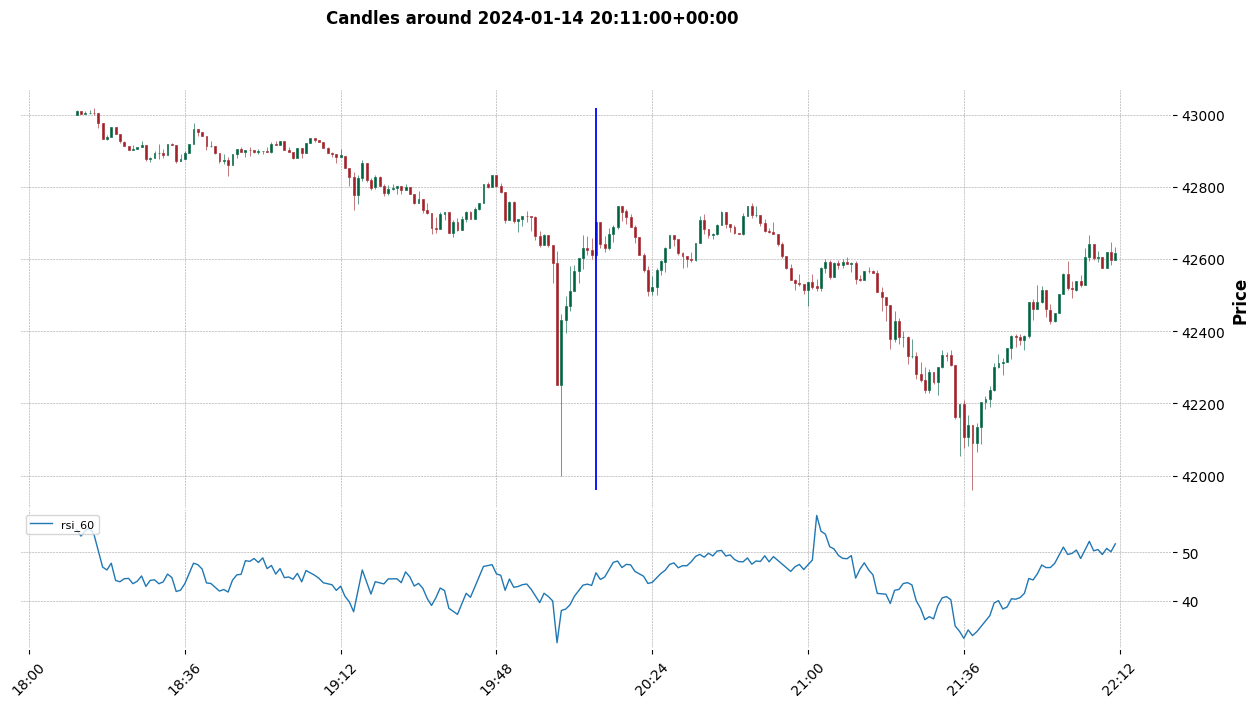

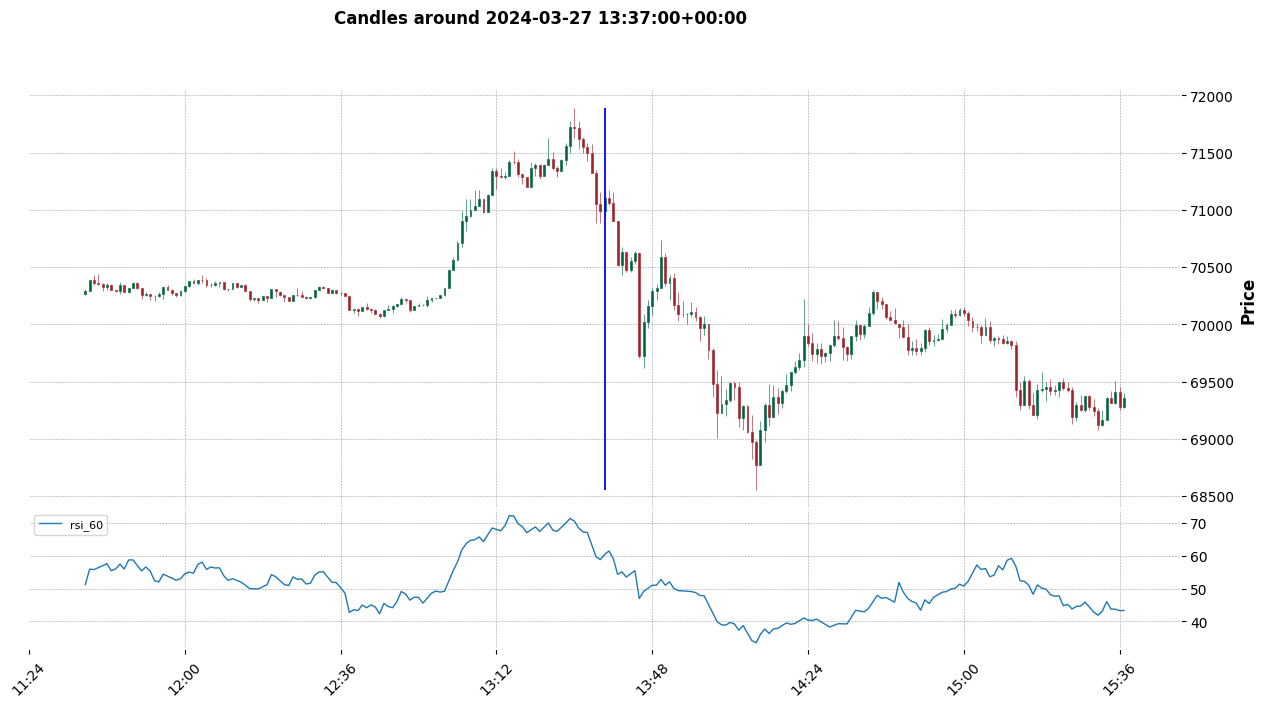

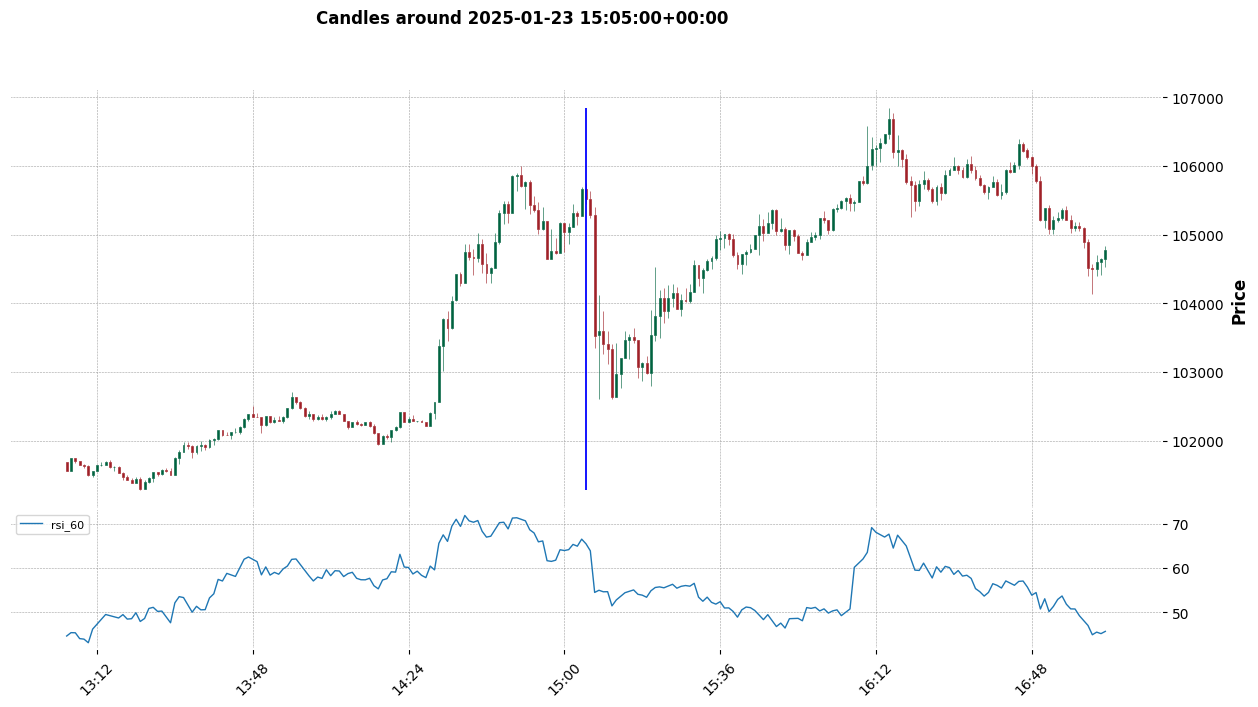

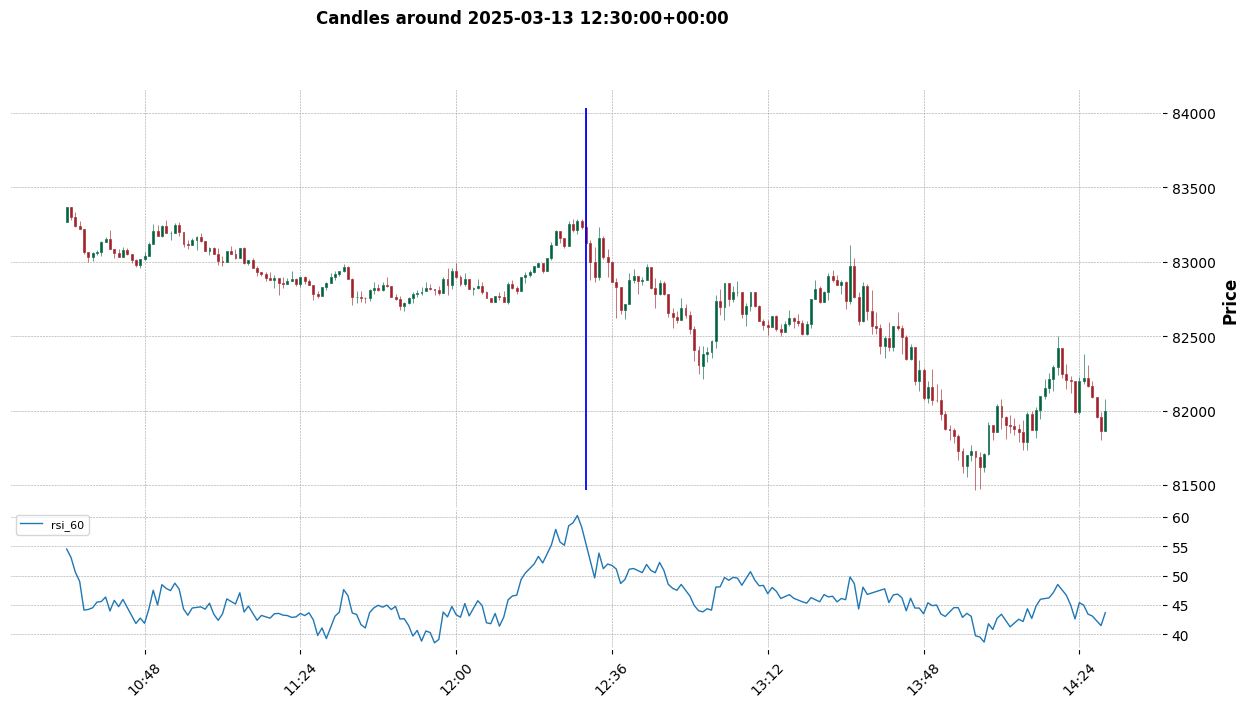

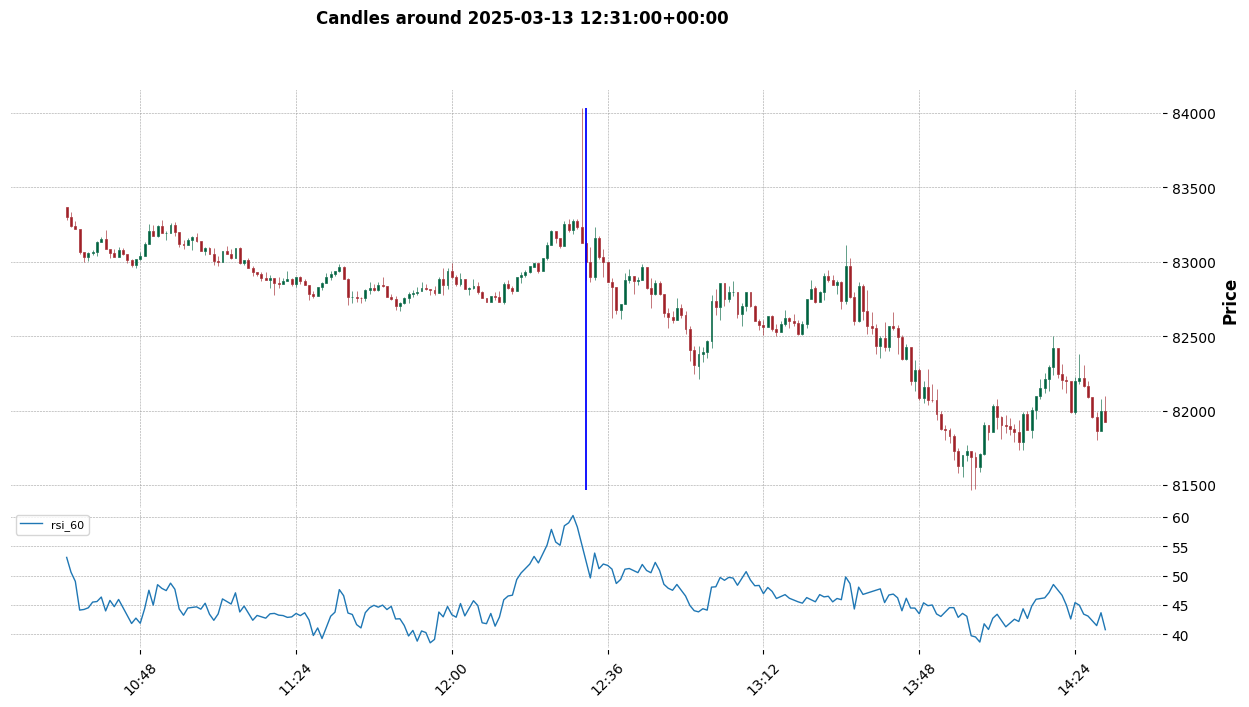

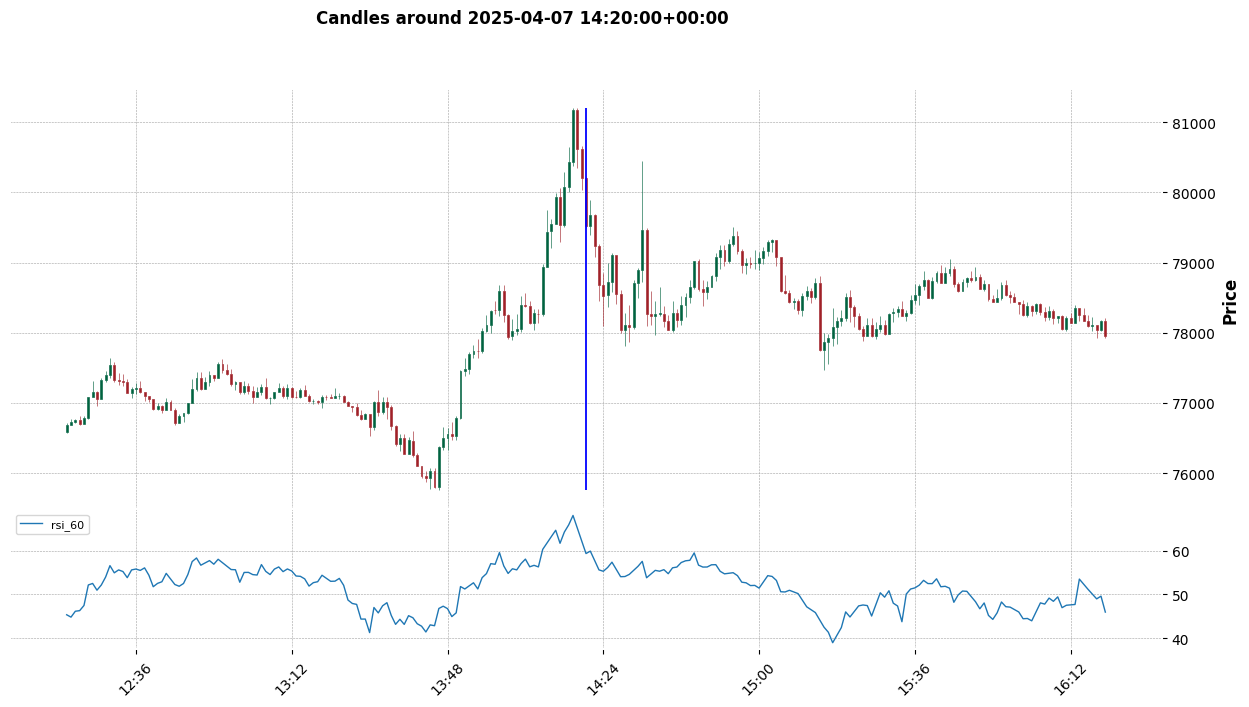

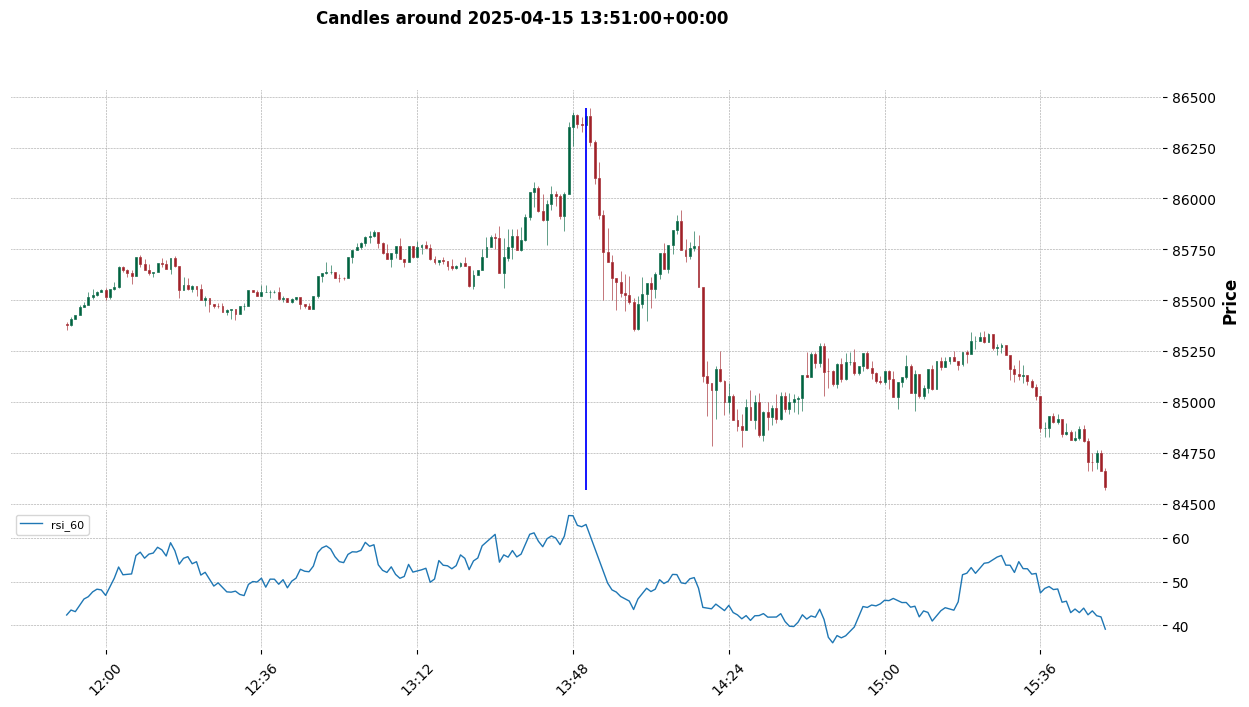

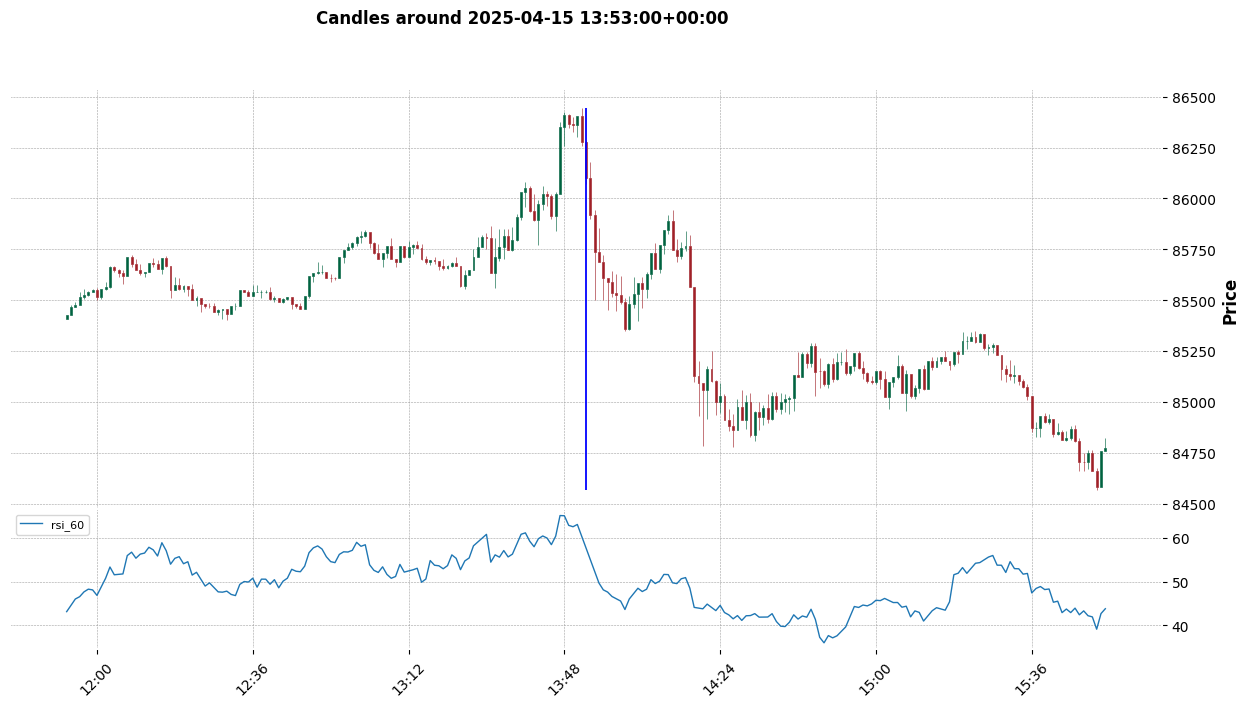

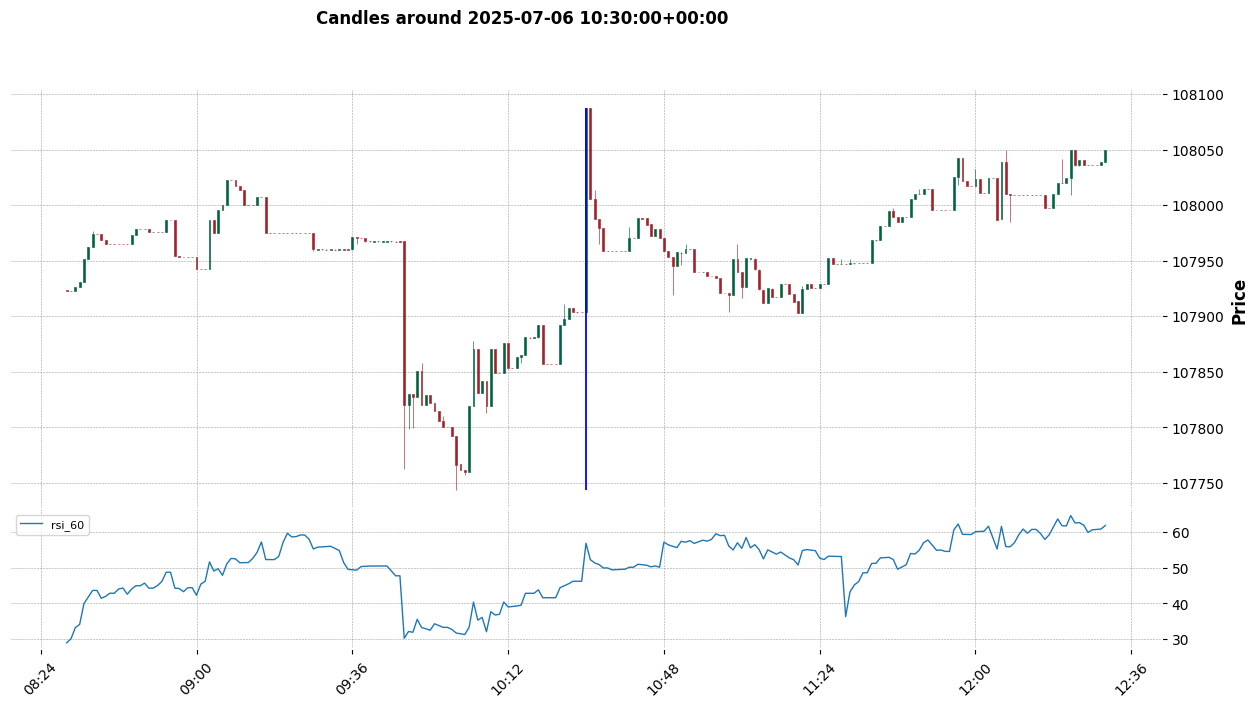

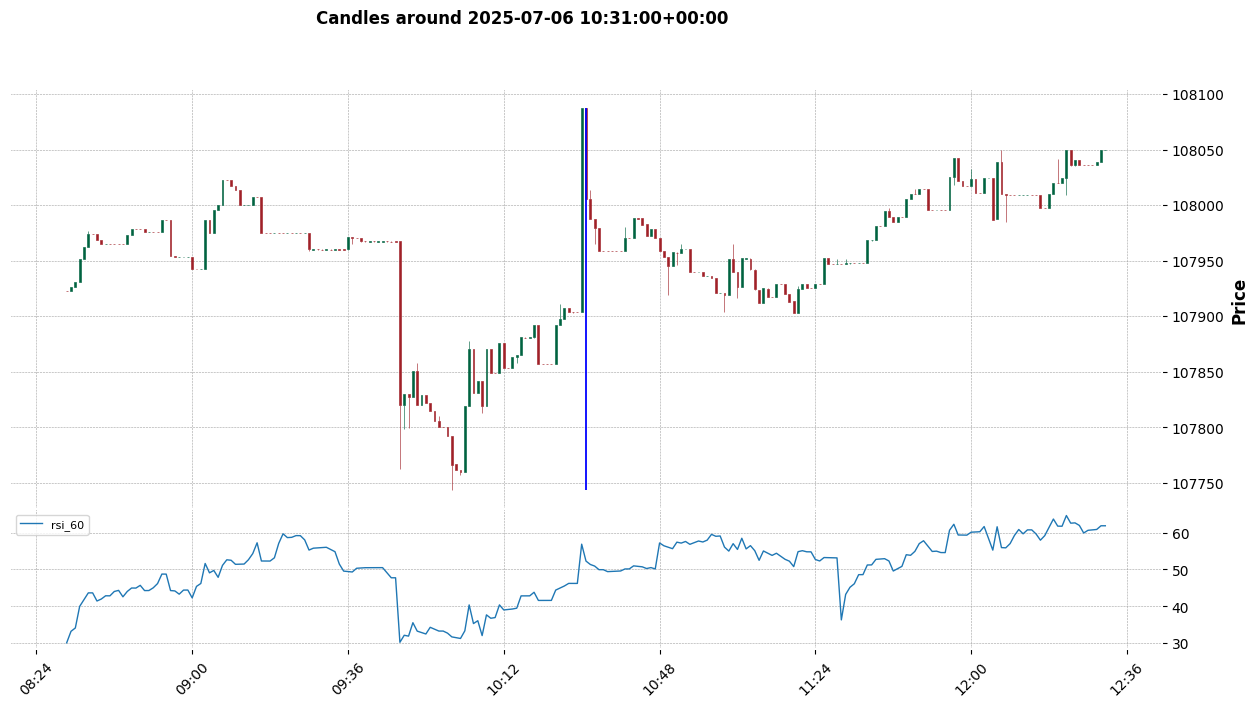

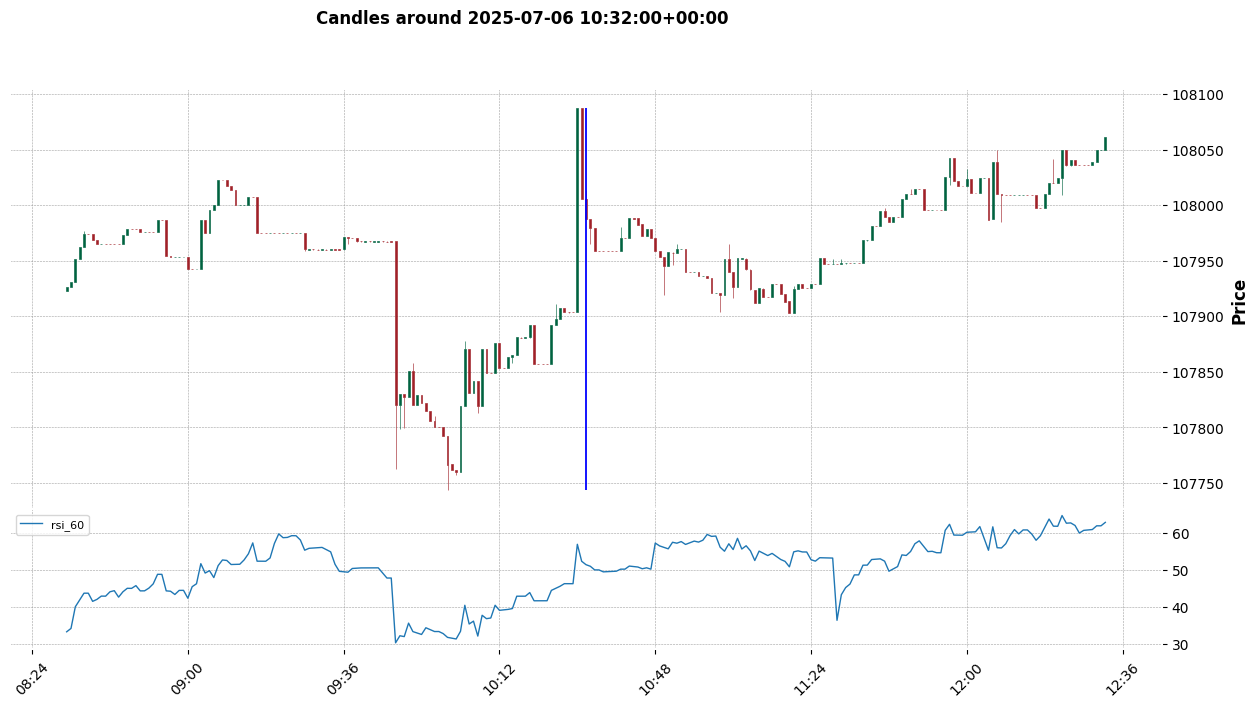

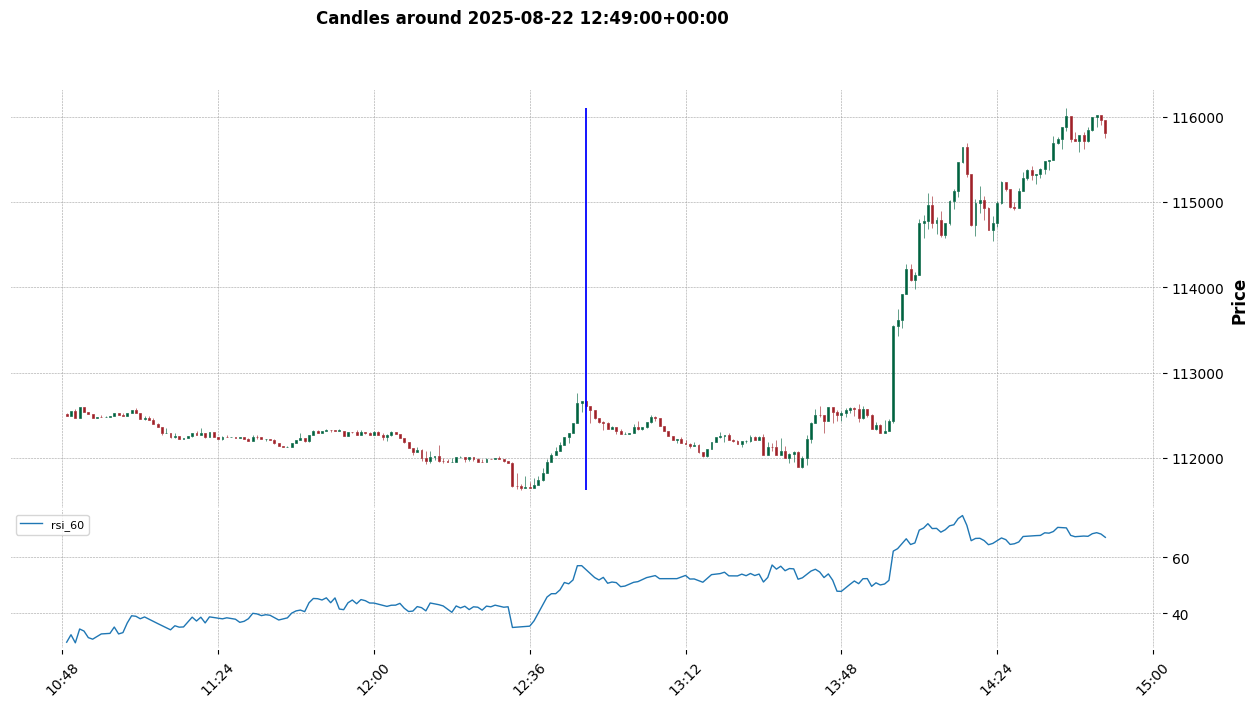

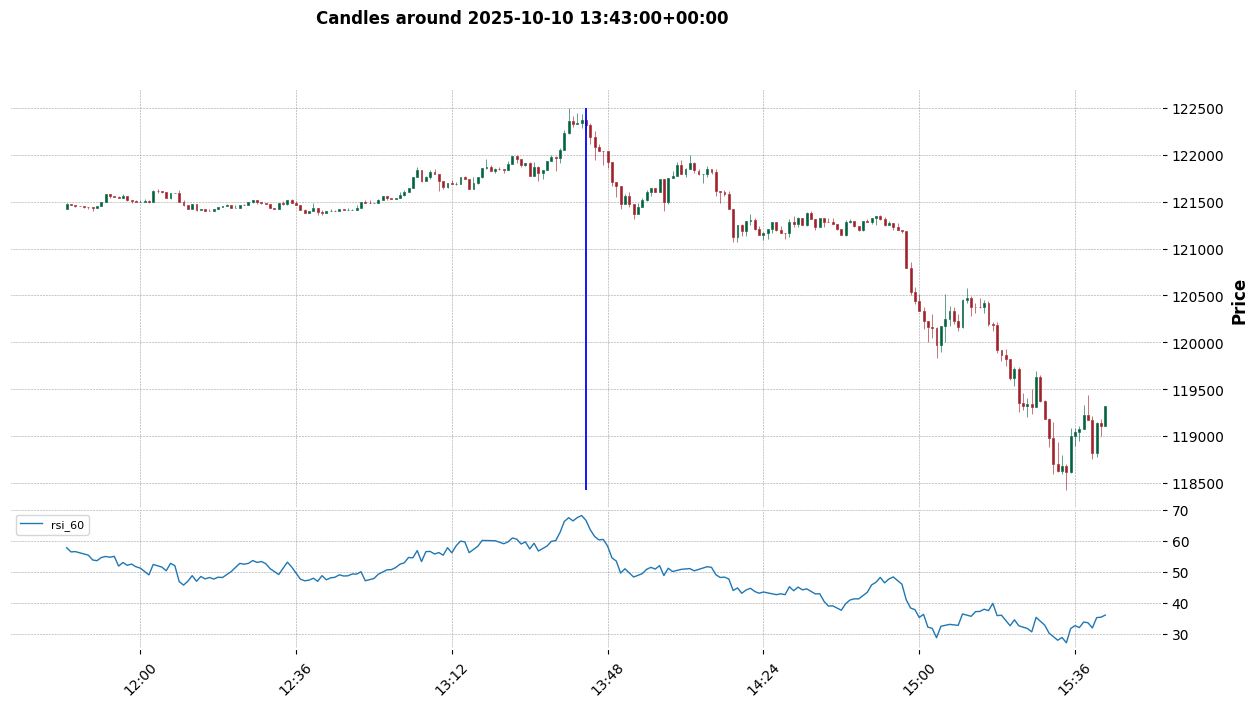

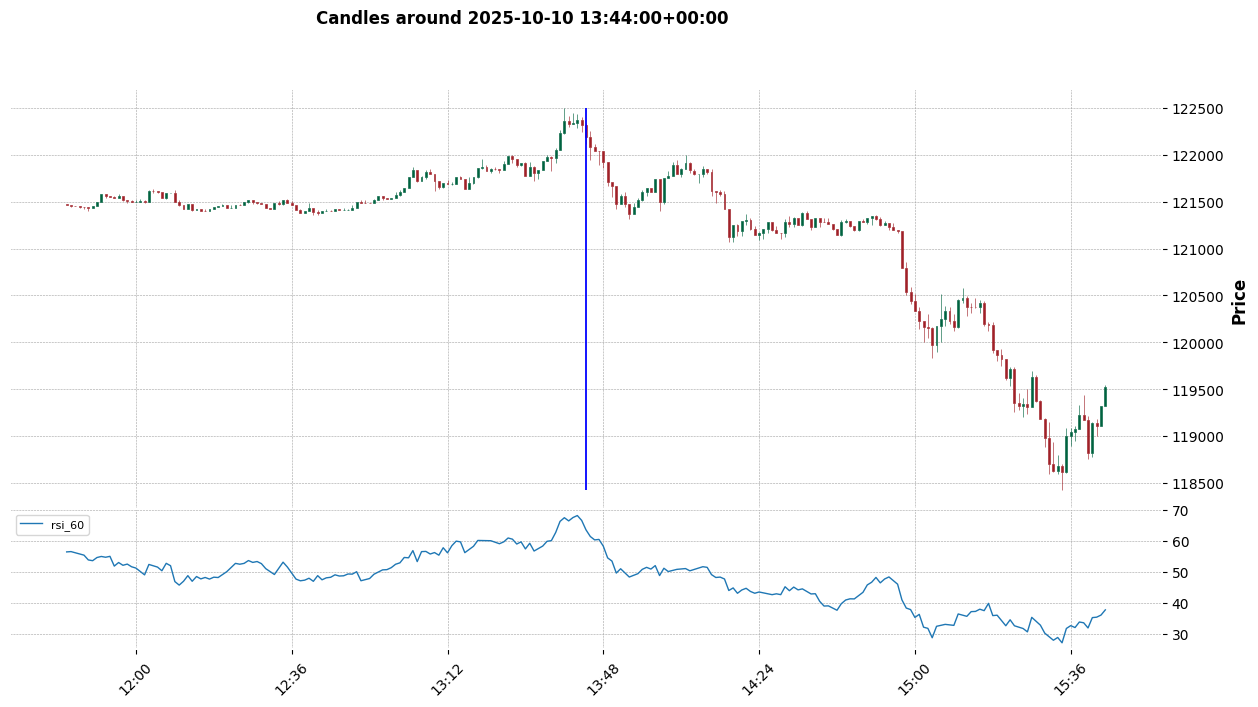

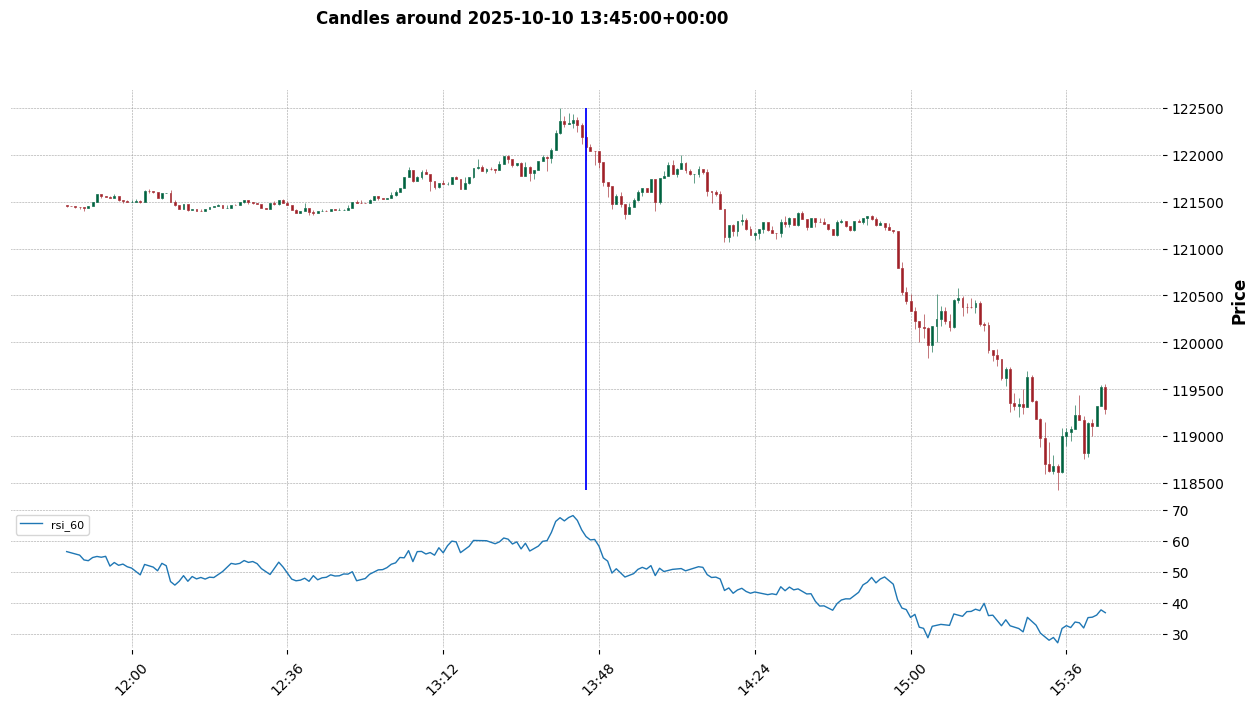

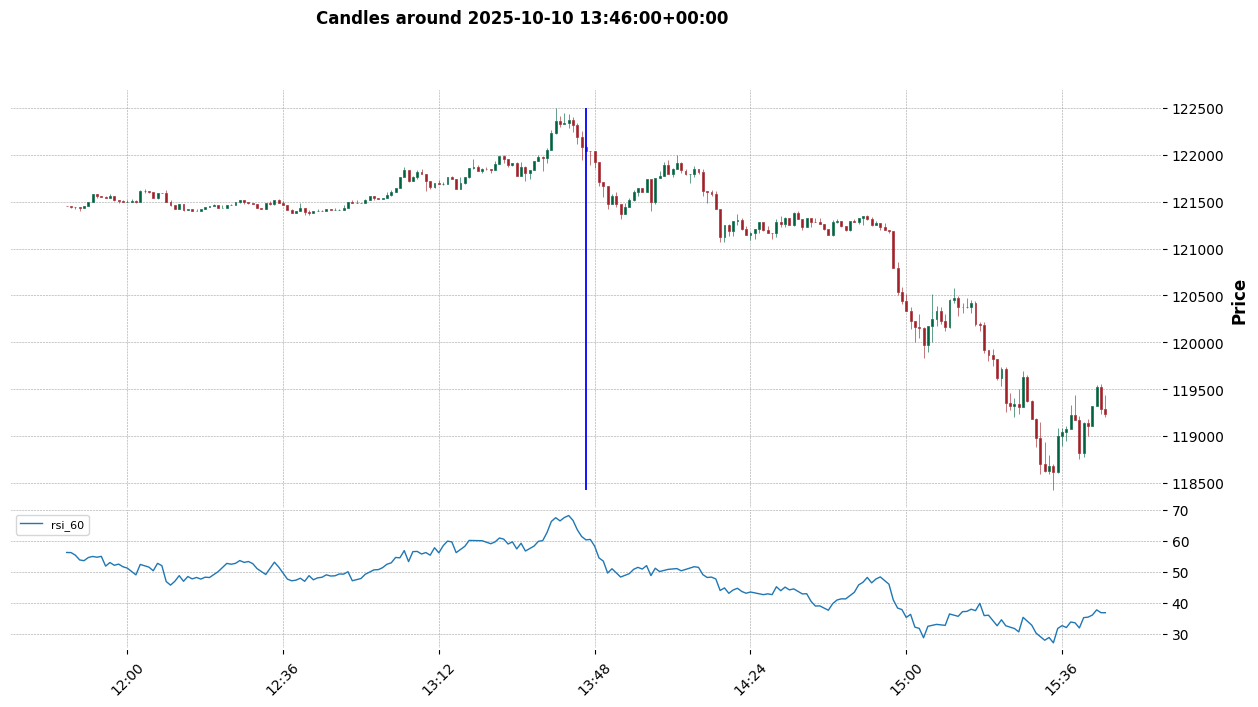

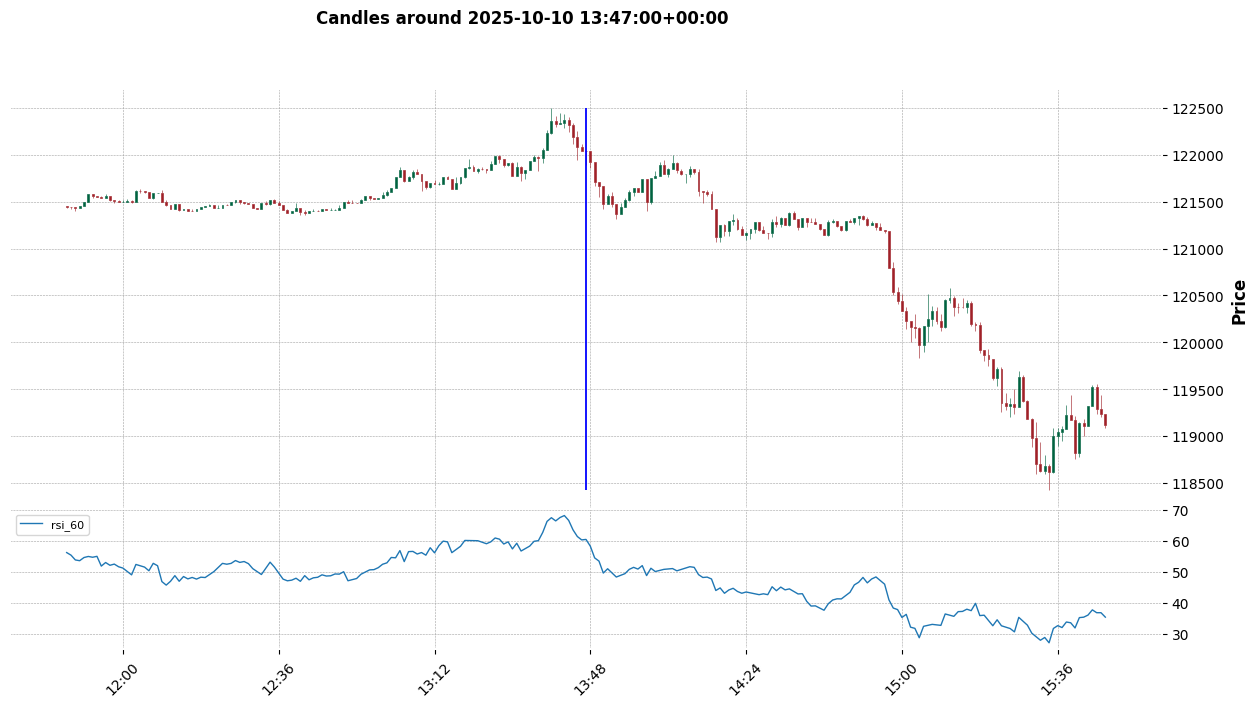

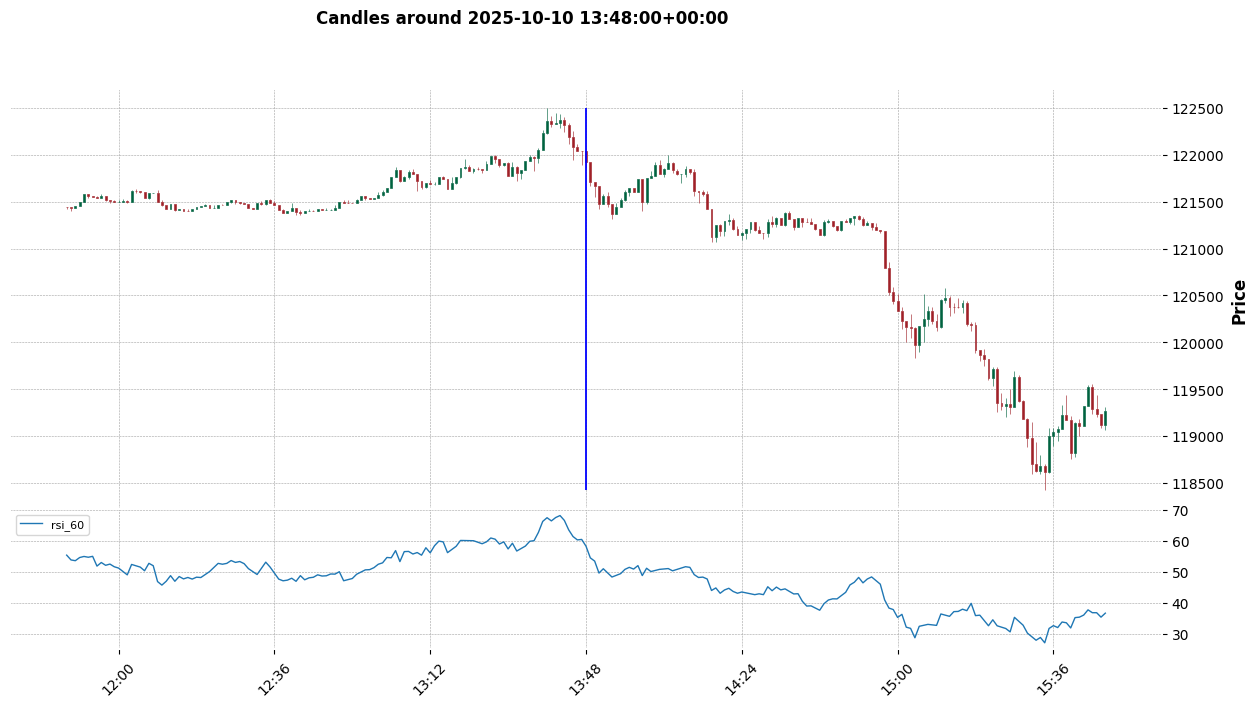

In [16]:
# !pip install mplfinance
from pipeline.visualiser import plot_candles_with_add_around_index

# ЕСЛИ ДАВАЛИ БУДУЩЕЕ, ТО РЕАЛЬНАЯ ТОЧКа ВХОДА СМЕЩЕНА ВПРАВО

LABEL_TO_SHOW = 6
SAMPLES = 100

add = {
    # 0: ['BBL_20_2.0', 'BBU_20_2.0', 'BBM_20_2.0'],
    1: ['rsi_60'],
    # 2: ['zScore_mean', 'zScore_median'],
}

count=0
for i, l in zip(anomaly_indx, sample_labels):
    if l == LABEL_TO_SHOW and count<=SAMPLES:
        count+=1
        plot_candles_with_add_around_index(
            df,
            style='charles',
            figsize=(16,8),
            center_idx=i,
            window=120,
            add=add,
            volume=False,
        )